In [1]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# ================================================================
# CELL 1 — GOOGLE DRIVE + PROJECT SETUP
# ================================================================

from pathlib import Path
import random
import numpy as np
import os

print("=" * 70)
print("ENERGYMOL-MLIP — MACE TRAINING AND VALIDATION")
print("=" * 70)

# ------------------------------------------------
# 1. Check Google Drive
# ------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive")

print("\nChecking Google Drive...")

if DRIVE_ROOT.exists():

    print("Google Drive path already available:")
    print(DRIVE_ROOT)

else:

    print("Google Drive is not mounted.")
    print("Mounting Google Drive...")

    from google.colab import drive

    drive.mount("/content/drive")

    assert DRIVE_ROOT.exists(), (
        "Google Drive mount completed, "
        "but MyDrive was not found."
    )

    print("Google Drive mounted successfully.")

# ------------------------------------------------
# 2. Project paths
# ------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/MLIP project"
)

PROCESSED_DIR = (
    PROJECT_DIR / "data" / "processed"
)

MODELS_DIR = (
    PROJECT_DIR / "models"
)

RESULTS_DIR = (
    PROJECT_DIR / "results"
)

METRICS_DIR = (
    RESULTS_DIR / "metrics"
)

FIGURES_DIR = (
    RESULTS_DIR / "figures"
)

# ------------------------------------------------
# 3. Create output directories
# ------------------------------------------------

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------
# 4. MACE input files
# ------------------------------------------------

TRAIN_FILE = (
    PROCESSED_DIR /
    "mace_train.extxyz"
)

VAL_FILE = (
    PROCESSED_DIR /
    "mace_validation.extxyz"
)

TEST_FILE = (
    PROCESSED_DIR /
    "mace_test_transfer.extxyz"
)

# ------------------------------------------------
# 5. Reproducibility
# ------------------------------------------------

SEED = 123

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------
# 6. Display paths
# ------------------------------------------------

print("\nProject directory:")
print(PROJECT_DIR)

print("\nInput datasets:")

print(
    "Training      :",
    TRAIN_FILE
)

print(
    "Validation    :",
    VAL_FILE
)

print(
    "Transfer test :",
    TEST_FILE
)

print("\nOutput directories:")

print(
    "Models        :",
    MODELS_DIR
)

print(
    "Metrics       :",
    METRICS_DIR
)

print(
    "Figures       :",
    FIGURES_DIR
)

# ------------------------------------------------
# 7. Check project
# ------------------------------------------------

assert PROJECT_DIR.exists(), (
    f"Project directory not found:\n"
    f"{PROJECT_DIR}"
)

assert PROCESSED_DIR.exists(), (
    f"Processed directory not found:\n"
    f"{PROCESSED_DIR}"
)

# ------------------------------------------------
# 8. Check MACE datasets
# ------------------------------------------------

print("\nChecking MACE datasets...")

print(
    "Training file exists      :",
    TRAIN_FILE.exists()
)

print(
    "Validation file exists    :",
    VAL_FILE.exists()
)

print(
    "Transfer-test file exists :",
    TEST_FILE.exists()
)

assert TRAIN_FILE.exists(), (
    f"Training dataset not found:\n"
    f"{TRAIN_FILE}"
)

assert VAL_FILE.exists(), (
    f"Validation dataset not found:\n"
    f"{VAL_FILE}"
)

assert TEST_FILE.exists(), (
    f"Transfer-test dataset not found:\n"
    f"{TEST_FILE}"
)

print("\nAll three MACE datasets found.")

print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

ENERGYMOL-MLIP — MACE TRAINING AND VALIDATION

Checking Google Drive...
Google Drive path already available:
/content/drive/MyDrive

Project directory:
/content/drive/MyDrive/MLIP project

Input datasets:
Training      : /content/drive/MyDrive/MLIP project/data/processed/mace_train.extxyz
Validation    : /content/drive/MyDrive/MLIP project/data/processed/mace_validation.extxyz
Transfer test : /content/drive/MyDrive/MLIP project/data/processed/mace_test_transfer.extxyz

Output directories:
Models        : /content/drive/MyDrive/MLIP project/models
Metrics       : /content/drive/MyDrive/MLIP project/results/metrics
Figures       : /content/drive/MyDrive/MLIP project/results/figures

Checking MACE datasets...
Training file exists      : True
Validation file exists    : True
Transfer-test file exists : True

All three MACE datasets found.

CELL 1 COMPLETE


In [2]:
# ================================================================
# CELL 2 — INSTALL MACE
# ================================================================

import sys
import subprocess

print("=" * 70)
print("INSTALLING MACE")
print("=" * 70)

print("\nPython:")
print(sys.version)

print("\nInstalling mace-torch...")

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "mace-torch"
])

print("\nMACE installation completed.")

print("\n" + "=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

INSTALLING MACE

Python:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

Installing mace-torch...

MACE installation completed.

CELL 2 COMPLETE


In [ ]:
# ============================================================
# CELL 3 — LOAD AND VALIDATE MACE DATASETS
# ============================================================

import os
import sys
import numpy as np
from pathlib import Path

from ase.io import read
from ase.calculators.singlepoint import SinglePointCalculator

print("=" * 70)
print("ENERGYMOL-MLIP — LOADING MACE DATASETS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Verify MACE installation
# ------------------------------------------------------------

try:
    import mace
    print("\nMACE import: SUCCESS")
    print("MACE location:", mace.__file__)
except Exception as e:
    raise RuntimeError(f"MACE import failed: {e}")

# ------------------------------------------------------------
# 2. Verify PyTorch
# ------------------------------------------------------------

import torch

print("\nPyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected device:", DEVICE)

# ------------------------------------------------------------
# 3. Define project paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

TRAIN_FILE = PROCESSED_DIR / "mace_train.extxyz"
VAL_FILE   = PROCESSED_DIR / "mace_validation.extxyz"
TEST_FILE  = PROCESSED_DIR / "mace_test_transfer.extxyz"

MODEL_DIR = PROJECT_DIR / "models"
METRICS_DIR = PROJECT_DIR / "results" / "metrics"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"

for directory in [MODEL_DIR, METRICS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 4. Confirm files
# ------------------------------------------------------------

for name, path in [
    ("Training", TRAIN_FILE),
    ("Validation", VAL_FILE),
    ("Transfer test", TEST_FILE),
]:
    print(f"{name:15s}: {path.exists()}")

assert TRAIN_FILE.exists(), f"Missing training file: {TRAIN_FILE}"
assert VAL_FILE.exists(), f"Missing validation file: {VAL_FILE}"
assert TEST_FILE.exists(), f"Missing transfer file: {TEST_FILE}"

# ------------------------------------------------------------
# 5. Load datasets
# ------------------------------------------------------------

print("\nLoading datasets...")

train_data = read(str(TRAIN_FILE), index=":")
val_data   = read(str(VAL_FILE), index=":")
test_data  = read(str(TEST_FILE), index=":")

print("Training configurations      :", len(train_data))
print("Validation configurations    :", len(val_data))
print("Transfer-test configurations:", len(test_data))

# ------------------------------------------------------------
# 6. Basic dataset validation
# ------------------------------------------------------------

def validate_dataset(dataset, dataset_name):

    print(f"\nChecking {dataset_name}...")

    energies = []
    force_shapes = []
    molecule_ids = []
    configuration_ids = []

    for i, atoms in enumerate(dataset):

        # Positions
        assert atoms.positions.shape == (len(atoms), 3), (
            f"{dataset_name}: invalid positions at index {i}"
        )

        # Calculator results
        assert atoms.calc is not None, (
            f"{dataset_name}: missing calculator at index {i}"
        )

        assert "energy" in atoms.calc.results, (
            f"{dataset_name}: missing energy at index {i}"
        )

        assert "forces" in atoms.calc.results, (
            f"{dataset_name}: missing forces at index {i}"
        )

        energy = float(atoms.calc.results["energy"])
        forces = np.asarray(atoms.calc.results["forces"], dtype=float)

        assert np.isfinite(energy), (
            f"{dataset_name}: non-finite energy at index {i}"
        )

        assert forces.shape == (len(atoms), 3), (
            f"{dataset_name}: invalid force shape at index {i}"
        )

        assert np.all(np.isfinite(forces)), (
            f"{dataset_name}: non-finite forces at index {i}"
        )

        energies.append(energy)
        force_shapes.append(forces.shape)

        molecule_ids.append(atoms.info.get("molecule_id"))
        configuration_ids.append(atoms.info.get("configuration_id"))

    # Check unique configuration IDs
    assert len(configuration_ids) == len(set(configuration_ids)), (
        f"{dataset_name}: duplicate configuration IDs detected"
    )

    print("  Configurations :", len(dataset))
    print("  Energy range   :", f"{min(energies):.6f} to {max(energies):.6f} eV")
    print("  Molecules      :", len(set(molecule_ids)))
    print("  Unique IDs     :", len(set(configuration_ids)))
    print("  Status         : PASSED")

    return {
        "n_configurations": len(dataset),
        "n_molecules": len(set(molecule_ids)),
        "energies": np.asarray(energies),
        "molecule_ids": molecule_ids,
        "configuration_ids": configuration_ids,
    }

# ------------------------------------------------------------
# 7. Validate all three datasets
# ------------------------------------------------------------

train_info = validate_dataset(train_data, "TRAINING")
val_info   = validate_dataset(val_data, "VALIDATION")
test_info  = validate_dataset(test_data, "TRANSFER TEST")

# ------------------------------------------------------------
# 8. Check molecule separation
# ------------------------------------------------------------

train_molecules = set(train_info["molecule_ids"])
val_molecules   = set(val_info["molecule_ids"])
test_molecules  = set(test_info["molecule_ids"])

assert train_molecules.isdisjoint(val_molecules)
assert train_molecules.isdisjoint(test_molecules)
assert val_molecules.isdisjoint(test_molecules)

print("\nMolecule-level separation: PASSED")

# ------------------------------------------------------------
# 9. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

print(f"Training      : {len(train_data)} configurations")
print(f"Validation    : {len(val_data)} configurations")
print(f"Transfer test : {len(test_data)} configurations")
print(f"Total         : {len(train_data) + len(val_data) + len(test_data)} configurations")
print(f"Device        : {DEVICE}")
print("Dataset integrity checks: PASSED")

ENERGYMOL-MLIP — LOADING MACE DATASETS

MACE import: SUCCESS
MACE location: /usr/local/lib/python3.13/dist-packages/mace/__init__.py

PyTorch version: 2.11.0+cpu
CUDA available : False
Selected device: cpu
Training       : True
Validation     : True
Transfer test  : True

Loading datasets...
Training configurations      : 372
Validation configurations    : 96
Transfer-test configurations: 95

Checking TRAINING...
  Configurations : 372
  Energy range   : -45035.169109 to -6740.865238 eV
  Molecules      : 16
  Unique IDs     : 372
  Status         : PASSED

Checking VALIDATION...
  Configurations : 96
  Energy range   : -15903.562672 to -9416.803557 eV
  Molecules      : 4
  Unique IDs     : 96
  Status         : PASSED

Checking TRANSFER TEST...
  Configurations : 95
  Energy range   : -26864.116682 to -6306.003036 eV
  Molecules      : 4
  Unique IDs     : 95
  Status         : PASSED

Molecule-level separation: PASSED

CELL 3 COMPLETE
Training      : 372 configurations
Validation   

In [ ]:
# ============================================================
# CELL 4 — MACE BASELINE TRAINING CONFIGURATION
# ============================================================

from pathlib import Path
import json
import random
import numpy as np
import torch

print("=" * 70)
print("ENERGYMOL-MLIP — MACE BASELINE CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("\nRandom seed:", SEED)

# ------------------------------------------------------------
# 2. Dataset sizes
# ------------------------------------------------------------

N_TRAIN = len(train_data)
N_VAL = len(val_data)
N_TEST = len(test_data)

print("\nDataset sizes:")
print("Training      :", N_TRAIN)
print("Validation    :", N_VAL)
print("Transfer test :", N_TEST)

# ------------------------------------------------------------
# 3. Baseline MACE architecture
# ------------------------------------------------------------

MACE_CONFIG = {
    "seed": SEED,

    # Model
    "model": "MACE",
    "hidden_irreps": "64x0e + 64x1o",
    "num_interactions": 2,
    "max_ell": 2,
    "r_max": 5.0,

    # Dataset / labels
    "energy_key": "energy",
    "forces_key": "forces",

    # Training
    "max_num_epochs": 100,
    "batch_size": 4,
    "valid_batch_size": 4,

    # Optimizer
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "weight_decay": 5e-7,

    # Loss weighting
    "energy_weight": 1.0,
    "forces_weight": 10.0,

    # Precision
    "default_dtype": "float32",

    # Device
    "device": DEVICE,
}

# ------------------------------------------------------------
# 4. Save configuration
# ------------------------------------------------------------

CONFIG_FILE = PROJECT_DIR / "configs" / "mace_baseline_config.json"
CONFIG_FILE.parent.mkdir(parents=True, exist_ok=True)

with open(CONFIG_FILE, "w") as f:
    json.dump(MACE_CONFIG, f, indent=2)

# ------------------------------------------------------------
# 5. Display frozen configuration
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("BASELINE MACE CONFIGURATION")
print("-" * 70)

for key, value in MACE_CONFIG.items():
    print(f"{key:22s}: {value}")

print("\nConfiguration saved to:")
print(CONFIG_FILE)

print("\n" + "=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

ENERGYMOL-MLIP — MACE BASELINE CONFIGURATION

Random seed: 123

Dataset sizes:
Training      : 372
Validation    : 96
Transfer test : 95

----------------------------------------------------------------------
BASELINE MACE CONFIGURATION
----------------------------------------------------------------------
seed                  : 123
model                 : MACE
hidden_irreps         : 64x0e + 64x1o
num_interactions      : 2
max_ell               : 2
r_max                 : 5.0
energy_key            : energy
forces_key            : forces
max_num_epochs        : 100
batch_size            : 4
valid_batch_size      : 4
optimizer             : Adam
learning_rate         : 0.001
weight_decay          : 5e-07
energy_weight         : 1.0
forces_weight         : 10.0
default_dtype         : float32
device                : cpu

Configuration saved to:
/content/drive/MyDrive/MLIP project/configs/mace_baseline_config.json

CELL 4 COMPLETE


In [ ]:
# ============================================================
# CELL 5 — CHECK INSTALLED MACE TRAINING INTERFACE
# ============================================================

import subprocess
import sys

print("=" * 70)
print("ENERGYMOL-MLIP — MACE TRAINING INTERFACE CHECK")
print("=" * 70)

result = subprocess.run(
    [sys.executable, "-m", "mace.cli.run_train", "--help"],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)

print("\n--- MACE TRAINING HELP ---\n")
print(result.stdout[:20000])

if result.stderr:
    print("\n--- STDERR ---\n")
    print(result.stderr[:5000])

print("\n" + "=" * 70)
print("CELL 5 COMPLETE")
print("=" * 70)

ENERGYMOL-MLIP — MACE TRAINING INTERFACE CHECK
Return code: 0

--- MACE TRAINING HELP ---

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
usage: run_train.py [-h] [--config CONFIG] --name NAME [--seed SEED]
                    [--work_dir WORK_DIR] [--log_dir LOG_DIR]
                    [--model_dir MODEL_DIR]
                    [--checkpoints_dir CHECKPOINTS_DIR]
                    [--results_dir RESULTS_DIR]
                    [--downloads_dir DOWNLOADS_DIR]
                    [--device {cpu,cuda,mps,xpu}]
                    [--default_dtype {float32,float64}] [--distributed]
                    [--launcher {slurm,torchrun,mpi,none}]
                    [--log_level LOG_LEVEL] [--plot PLOT]
                    [--plot_frequency PLOT_FREQUENCY]
                    [--plot_interaction_e PLOT_INTERACTION_E]
                    [--error_table {PerAtomRMSE,TotalRMSE,PerAtomRMSEstressvirials,PerAtomMAEstressvirials,PerAtomMAE,To

In [ ]:
# ============================================================
# CELL 6A — DIAGNOSE MACE TRAINING COMMAND
# ============================================================

import subprocess
import sys
from pathlib import Path

print("=" * 70)
print("ENERGYMOL-MLIP — MACE TRAINING COMMAND DIAGNOSTIC")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

TRAIN_FILE = PROJECT_DIR / "data" / "processed" / "mace_train.extxyz"
VAL_FILE   = PROJECT_DIR / "data" / "processed" / "mace_validation.extxyz"
TEST_FILE  = PROJECT_DIR / "data" / "processed" / "mace_test_transfer.extxyz"

RESULTS_DIR = PROJECT_DIR / "results" / "mace_baseline"
MODEL_DIR = PROJECT_DIR / "models" / "mace_baseline"
LOG_DIR = RESULTS_DIR / "logs"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

cmd = [
    sys.executable,
    "-m", "mace.cli.run_train",

    "--name", "energymol_mace_baseline",
    "--seed", "123",

    "--work_dir", str(RESULTS_DIR),
    "--log_dir", str(LOG_DIR),
    "--model_dir", str(MODEL_DIR),
    "--checkpoints_dir", str(CHECKPOINT_DIR),
    "--results_dir", str(RESULTS_DIR),

    "--device", "cpu",
    "--default_dtype", "float32",

    "--model", "MACE",
    "--r_max", "5.0",
    "--max_ell", "2",
    "--num_interactions", "2",
    "--hidden_irreps", "64x0e + 64x1o",

    "--compute_forces", "true",

    "--train_file", str(TRAIN_FILE),
    "--valid_file", str(VAL_FILE),
    "--test_file", str(TEST_FILE),

    "--num_workers", "0",

    "--loss", "ef",
    "--energy_weight", "1.0",
    "--forces_weight", "10.0",

    "--optimizer", "adam",
    "--lr", "0.001",
    "--weight_decay", "5e-7",

    "--batch_size", "4",
    "--valid_batch_size", "4",
    "--max_num_epochs", "100",

    "--eval_interval", "1",
    "--error_table", "PerAtomRMSE",

    "--plot", "true",
    "--plot_frequency", "0",

    "--keep_checkpoints",

    # Diagnostic only
    "--dry_run",
]

print("\nRunning MACE in DRY-RUN mode...")
print("No training will be performed.\n")

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True
)

print("=" * 70)
print("RETURN CODE")
print("=" * 70)
print(result.returncode)

print("\n" + "=" * 70)
print("STDOUT")
print("=" * 70)
print(result.stdout[-15000:] if result.stdout else "(empty)")

print("\n" + "=" * 70)
print("STDERR")
print("=" * 70)
print(result.stderr[-15000:] if result.stderr else "(empty)")

print("\n" + "=" * 70)
print("CELL 6A COMPLETE")
print("=" * 70)

ENERGYMOL-MLIP — MACE TRAINING COMMAND DIAGNOSTIC

Running MACE in DRY-RUN mode...
No training will be performed.

RETURN CODE
1

STDOUT
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-10-03 10:31:20.486 INFO: ===========VERIFYING SETTINGS===========
2026-10-03 10:31:21.101 INFO: MACE version: 0.3.16
2026-10-03 10:31:21.102 INFO: Using CPU
2026-10-03 10:31:21.202 INFO: ===========LOADING INPUT DATA===========
2026-10-03 10:31:21.203 INFO: Using heads: ['Default']
2026-10-03 10:31:21.203 INFO: Using the key specifications to parse data:
2026-10-03 10:31:21.203 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'REF_forces', 'charges': 'REF_charges'})
2026-10-03 10:31:21.204 INFO: ====

In [ ]:
# ============================================================
# CELL 6B — CREATE MACE-COMPATIBLE EXTXYZ DATASETS
# ============================================================

from pathlib import Path
import numpy as np
from ase.io import read, write

print("=" * 70)
print("ENERGYMOL-MLIP — PREPARING MACE 0.3.16 DATASETS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MACE_DATA_DIR = PROCESSED_DIR / "mace"

MACE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Input / output files
# ------------------------------------------------------------

input_files = {
    "train": PROCESSED_DIR / "mace_train.extxyz",
    "validation": PROCESSED_DIR / "mace_validation.extxyz",
    "transfer": PROCESSED_DIR / "mace_test_transfer.extxyz",
}

output_files = {
    "train": MACE_DATA_DIR / "mace_train_mace0316.extxyz",
    "validation": MACE_DATA_DIR / "mace_validation_mace0316.extxyz",
    "transfer": MACE_DATA_DIR / "mace_test_transfer_mace0316.extxyz",
}

# ------------------------------------------------------------
# Conversion function
# ------------------------------------------------------------

def convert_for_mace(input_file, output_file):

    atoms_list = read(str(input_file), index=":")

    converted = []

    for atoms in atoms_list:

        # ----------------------------------------------------
        # Obtain DFT labels from the ASE calculator
        # ----------------------------------------------------

        assert atoms.calc is not None, (
            f"Missing calculator in {input_file}"
        )

        results = atoms.calc.results

        assert "energy" in results, (
            f"Missing energy in {input_file}"
        )

        assert "forces" in results, (
            f"Missing forces in {input_file}"
        )

        energy = float(results["energy"])
        forces = np.asarray(results["forces"], dtype=float)

        assert np.isfinite(energy)
        assert forces.shape == (len(atoms), 3)
        assert np.all(np.isfinite(forces))

        # ----------------------------------------------------
        # Make independent copy
        # ----------------------------------------------------

        new_atoms = atoms.copy()

        # ----------------------------------------------------
        # Add MACE 0.3.16 labels
        # ----------------------------------------------------

        new_atoms.info["REF_energy"] = energy
        new_atoms.arrays["REF_forces"] = forces

        # ----------------------------------------------------
        # Remove dependence on SinglePointCalculator
        # ----------------------------------------------------

        new_atoms.calc = None

        converted.append(new_atoms)

    # --------------------------------------------------------
    # Write MACE-compatible EXTXYZ
    # --------------------------------------------------------

    write(
        str(output_file),
        converted,
        format="extxyz"
    )

    return converted


# ------------------------------------------------------------
# Convert all three datasets
# ------------------------------------------------------------

for split in ["train", "validation", "transfer"]:

    print(f"\nConverting {split} dataset...")

    converted = convert_for_mace(
        input_files[split],
        output_files[split]
    )

    print("  Input configurations :", len(converted))
    print("  Output file          :", output_files[split])


# ------------------------------------------------------------
# Reload and verify exactly as MACE will see them
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFYING MACE LABELS")
print("=" * 70)

for split in ["train", "validation", "transfer"]:

    atoms_list = read(
        str(output_files[split]),
        index=":"
    )

    print(f"\n{split.upper()}")
    print("-" * 50)

    print("Configurations:", len(atoms_list))

    first = atoms_list[0]

    print("Info keys:")
    print(list(first.info.keys()))

    print("Array keys:")
    print(list(first.arrays.keys()))

    assert "REF_energy" in first.info
    assert "REF_forces" in first.arrays

    assert np.isfinite(float(first.info["REF_energy"]))

    forces = np.asarray(first.arrays["REF_forces"], dtype=float)

    assert forces.shape == (len(first), 3)
    assert np.all(np.isfinite(forces))

    print("REF_energy:", first.info["REF_energy"])
    print("REF_forces shape:", forces.shape)
    print("Status: PASSED")


print("\n" + "=" * 70)
print("CELL 6B COMPLETE")
print("=" * 70)

print("\nMACE-compatible files:")
for path in output_files.values():
    print(path)

ENERGYMOL-MLIP — PREPARING MACE 0.3.16 DATASETS

Converting train dataset...
  Input configurations : 372
  Output file          : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_train_mace0316.extxyz

Converting validation dataset...
  Input configurations : 96
  Output file          : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_validation_mace0316.extxyz

Converting transfer dataset...
  Input configurations : 95
  Output file          : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_test_transfer_mace0316.extxyz

VERIFYING MACE LABELS

TRAIN
--------------------------------------------------
Configurations: 372
Info keys:
['M03_C001', 'naphthalene', 'family', 'source', 'configuration_id', 'molecule_id', 'molecule_name', 'dft_method', 'dft_basis', 'dft_software', 'energy_eV', 'REF_energy']
Array keys:
['numbers', 'positions', 'REF_forces']
REF_energy: -10481.147628403158
REF_forces shape: (18, 3)
Status: PASSED

VALIDATION
-----------------

In [ ]:
# ============================================================
# CELL 6D — MACE TRAINING DIAGNOSTIC
# ============================================================

import subprocess
import sys
from pathlib import Path

print("=" * 70)
print("ENERGYMOL-MLIP — MACE TRAINING DIAGNOSTIC")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

TRAIN_FILE = PROJECT_DIR / "data/processed/mace/mace_train_mace0316.extxyz"
VALID_FILE = PROJECT_DIR / "data/processed/mace/mace_validation_mace0316.extxyz"
TEST_FILE  = PROJECT_DIR / "data/processed/mace/mace_test_transfer_mace0316.extxyz"

MODEL_DIR = PROJECT_DIR / "models/mace_baseline"
RESULTS_DIR = PROJECT_DIR / "results/mace_baseline"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Checking files...")
print("TRAIN :", TRAIN_FILE.exists(), TRAIN_FILE)
print("VALID :", VALID_FILE.exists(), VALID_FILE)
print("TEST  :", TEST_FILE.exists(), TEST_FILE)

# ------------------------------------------------------------
# Exact same frozen baseline
# ------------------------------------------------------------

cmd = [
    sys.executable,
    "-m",
    "mace.cli.run_train",

    "--name", "mace_baseline",

    "--train_file", str(TRAIN_FILE),
    "--valid_file", str(VALID_FILE),
    "--test_file", str(TEST_FILE),

    "--model", "MACE",

    "--hidden_irreps", "64x0e + 64x1o",
    "--num_interactions", "2",
    "--max_ell", "2",
    "--r_max", "5.0",

    "--compute_forces",

    "--energy_key", "REF_energy",
    "--forces_key", "REF_forces",

    "--loss", "ef",
    "--energy_weight", "1.0",
    "--forces_weight", "10.0",

    "--optimizer", "adam",
    "--lr", "0.001",
    "--weight_decay", "5e-7",

    "--batch_size", "4",
    "--valid_batch_size", "4",

    "--max_num_epochs", "100",
    "--eval_interval", "1",

    "--default_dtype", "float32",
    "--device", "cpu",
    "--num_workers", "0",

    "--seed", "123",

    "--checkpoints_dir", str(MODEL_DIR),
    "--model_dir", str(MODEL_DIR),

    "--error_table", "PerAtomRMSE",
]

print("\nCommand:")
print(" ".join(cmd))

print("\n" + "=" * 70)
print("RUNNING MACE")
print("=" * 70)

process = subprocess.run(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print(process.stdout)

print("\n" + "=" * 70)
print("MACE PROCESS FINISHED")
print("=" * 70)
print("Return code:", process.returncode)

if process.returncode != 0:
    print("\nMACE FAILED.")
    print("The complete error above is the information we need.")
else:
    print("\nMACE TRAINING COMPLETED SUCCESSFULLY.")

ENERGYMOL-MLIP — MACE TRAINING DIAGNOSTIC
Checking files...
TRAIN : True /content/drive/MyDrive/MLIP project/data/processed/mace/mace_train_mace0316.extxyz
VALID : True /content/drive/MyDrive/MLIP project/data/processed/mace/mace_validation_mace0316.extxyz
TEST  : True /content/drive/MyDrive/MLIP project/data/processed/mace/mace_test_transfer_mace0316.extxyz

Command:
/usr/bin/python3 -m mace.cli.run_train --name mace_baseline --train_file /content/drive/MyDrive/MLIP project/data/processed/mace/mace_train_mace0316.extxyz --valid_file /content/drive/MyDrive/MLIP project/data/processed/mace/mace_validation_mace0316.extxyz --test_file /content/drive/MyDrive/MLIP project/data/processed/mace/mace_test_transfer_mace0316.extxyz --model MACE --hidden_irreps 64x0e + 64x1o --num_interactions 2 --max_ell 2 --r_max 5.0 --compute_forces --energy_key REF_energy --forces_key REF_forces --loss ef --energy_weight 1.0 --forces_weight 10.0 --optimizer adam --lr 0.001 --weight_decay 5e-7 --batch_size 4 --

In [ ]:
# ============================================================
# CELL 6F — MACE BASELINE TRAINING
# MACE 0.3.16 + required atomic reference energies
# ============================================================

import subprocess
import sys
from pathlib import Path

print("=" * 70)
print("ENERGYMOL-MLIP — MACE BASELINE TRAINING")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

TRAIN_FILE = PROJECT_DIR / "data/processed/mace/mace_train_mace0316.extxyz"
VALID_FILE = PROJECT_DIR / "data/processed/mace/mace_validation_mace0316.extxyz"
TEST_FILE  = PROJECT_DIR / "data/processed/mace/mace_test_transfer_mace0316.extxyz"

MODEL_DIR = PROJECT_DIR / "models/mace_baseline"
RESULTS_DIR = PROJECT_DIR / "results/mace_baseline"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Check files
# ------------------------------------------------------------

assert TRAIN_FILE.exists()
assert VALID_FILE.exists()
assert TEST_FILE.exists()

print("\nDataset files:")
print("Training      :", TRAIN_FILE)
print("Validation    :", VALID_FILE)
print("Transfer test :", TEST_FILE)

# ------------------------------------------------------------
# FROZEN MODEL SETTINGS
# ------------------------------------------------------------

cmd = [
    sys.executable,
    "-m", "mace.cli.run_train",

    "--name", "mace_baseline",

    "--train_file", str(TRAIN_FILE),
    "--valid_file", str(VALID_FILE),
    "--test_file", str(TEST_FILE),

    "--model", "MACE",

    "--r_max", "5.0",
    "--max_ell", "2",
    "--num_interactions", "2",
    "--hidden_irreps", "64x0e + 64x1o",

    "--compute_forces", "true",

    "--energy_key", "REF_energy",
    "--forces_key", "REF_forces",

    # --------------------------------------------------------
    # Atomic reference energies
    # MACE 0.3.16 requires E0s.
    # "average" calculates atomic energies from the training set.
    # --------------------------------------------------------
    "--E0s", "average",

    "--loss", "ef",
    "--energy_weight", "1.0",
    "--forces_weight", "10.0",

    "--optimizer", "adam",
    "--lr", "0.001",
    "--weight_decay", "5e-7",

    "--batch_size", "4",
    "--valid_batch_size", "4",

    "--max_num_epochs", "100",
    "--eval_interval", "1",

    "--default_dtype", "float32",
    "--device", "cpu",
    "--num_workers", "0",

    "--seed", "123",

    "--model_dir", str(MODEL_DIR),
    "--checkpoints_dir", str(MODEL_DIR),
    "--results_dir", str(RESULTS_DIR),

    "--error_table", "PerAtomRMSE",

    "--keep_checkpoints",
]

print("\nFrozen baseline:")
print("Model         : MACE")
print("Interactions  : 2")
print("Hidden irreps : 64x0e + 64x1o")
print("max_ell       : 2")
print("r_max         : 5.0 Å")
print("Epochs        : 100")
print("Batch size    : 4")
print("Learning rate : 0.001")
print("Energy weight : 1.0")
print("Force weight  : 10.0")
print("E0s           : average")
print("Device        : CPU")
print("Precision     : float32")
print("Seed          : 123")

print("\n" + "=" * 70)
print("TRAINING STARTING")
print("=" * 70)

process = subprocess.run(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print(process.stdout)

print("\n" + "=" * 70)
print("MACE TRAINING PROCESS FINISHED")
print("=" * 70)
print("Return code:", process.returncode)

if process.returncode != 0:
    raise RuntimeError(
        "MACE training failed. The complete MACE output is shown above."
    )

print("\nMACE BASELINE TRAINING COMPLETED SUCCESSFULLY.")
print("Model directory  :", MODEL_DIR)
print("Results directory:", RESULTS_DIR)

ENERGYMOL-MLIP — MACE BASELINE TRAINING

Dataset files:
Training      : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_train_mace0316.extxyz
Validation    : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_validation_mace0316.extxyz
Transfer test : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_test_transfer_mace0316.extxyz

Frozen baseline:
Model         : MACE
Interactions  : 2
Hidden irreps : 64x0e + 64x1o
max_ell       : 2
r_max         : 5.0 Å
Epochs        : 100
Batch size    : 4
Learning rate : 0.001
Energy weight : 1.0
Force weight  : 10.0
E0s           : average
Device        : CPU
Precision     : float32
Seed          : 123

TRAINING STARTING
/usr/local/lib/python3.13/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.joi

In [ ]:
# ============================================================
# CELL 6C — MACE BASELINE TRAINING
# ============================================================

import subprocess
import sys
from pathlib import Path

print("=" * 70)
print("ENERGYMOL-MLIP — MACE BASELINE TRAINING")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

TRAIN_FILE = (
    PROJECT_DIR / "data" / "processed" / "mace"
    / "mace_train_mace0316.extxyz"
)
VAL_FILE = (
    PROJECT_DIR / "data" / "processed" / "mace"
    / "mace_validation_mace0316.extxyz"
)
TEST_FILE = (
    PROJECT_DIR / "data" / "processed" / "mace"
    / "mace_test_transfer_mace0316.extxyz"
)

assert TRAIN_FILE.exists(), f"Missing: {TRAIN_FILE}"
assert VAL_FILE.exists(), f"Missing: {VAL_FILE}"
assert TEST_FILE.exists(), f"Missing: {TEST_FILE}"

MODEL_DIR = PROJECT_DIR / "models" / "mace_baseline"
RESULTS_DIR = PROJECT_DIR / "results" / "mace_baseline"
LOG_DIR = RESULTS_DIR / "logs"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

for directory in [MODEL_DIR, RESULTS_DIR, LOG_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

EXPERIMENT_NAME = "energymol_mace_baseline"

cmd = [
    sys.executable,
    "-m", "mace.cli.run_train",

    "--name", EXPERIMENT_NAME,
    "--seed", "123",

    "--work_dir", str(RESULTS_DIR),
    "--log_dir", str(LOG_DIR),
    "--model_dir", str(MODEL_DIR),
    "--checkpoints_dir", str(CHECKPOINT_DIR),
    "--results_dir", str(RESULTS_DIR),

    "--device", "cpu",
    "--default_dtype", "float32",

    "--model", "MACE",
    "--E0s", "average",
    "--r_max", "5.0",
    "--max_ell", "2",
    "--num_interactions", "2",
    "--hidden_irreps", "64x0e + 64x1o",

    "--compute_forces", "true",

    "--train_file", str(TRAIN_FILE),
    "--valid_file", str(VAL_FILE),
    "--test_file", str(TEST_FILE),

    "--num_workers", "0",

    "--loss", "weighted",
    "--energy_weight", "1.0",
    "--forces_weight", "10.0",

    "--optimizer", "adam",
    "--lr", "0.001",
    "--weight_decay", "5e-7",

    "--batch_size", "4",
    "--valid_batch_size", "4",
    "--max_num_epochs", "100",

    "--eval_interval", "1",
    "--error_table", "PerAtomRMSE",

    "--plot", "true",
    "--plot_frequency", "0",

    "--keep_checkpoints",
]

print("\nDataset files:")
print("Training      :", TRAIN_FILE)
print("Validation    :", VAL_FILE)
print("Transfer test :", TEST_FILE)

print("\nFrozen baseline:")
print("Model         : MACE")
print("E0s           : average")
print("Interactions  : 2")
print("Hidden irreps : 64x0e + 64x1o")
print("max_ell       : 2")
print("r_max         : 5.0 Å")
print("Epochs        : 100")
print("Batch size    : 4")
print("Learning rate : 0.001")
print("Loss type     : weighted")
print("Energy weight : 1.0")
print("Force weight  : 10.0")
print("Device        : CPU")
print("Precision     : float32")
print("Seed          : 123")

print("\n" + "=" * 70)
print("TRAINING STARTING")
print("=" * 70)

process = subprocess.run(cmd, capture_output=True, text=True)

print(process.stdout[-4000:])
print("\n--- STDERR (tail) ---")
print(process.stderr[-4000:])

print("\n" + "=" * 70)
print("MACE TRAINING PROCESS FINISHED")
print("=" * 70)

print("Return code:", process.returncode)

if process.returncode != 0:
    raise RuntimeError(
        "MACE training failed. Send the MACE error output above."
    )

print("\n" + "=" * 70)
print("CELL 6C COMPLETE")
print("=" * 70)

ENERGYMOL-MLIP — MACE BASELINE TRAINING

Dataset files:
Training      : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_train_mace0316.extxyz
Validation    : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_validation_mace0316.extxyz
Transfer test : /content/drive/MyDrive/MLIP project/data/processed/mace/mace_test_transfer_mace0316.extxyz

Frozen baseline:
Model         : MACE
E0s           : average
Interactions  : 2
Hidden irreps : 64x0e + 64x1o
max_ell       : 2
r_max         : 5.0 Å
Epochs        : 100
Batch size    : 4
Learning rate : 0.001
Loss type     : weighted
Energy weight : 1.0
Force weight  : 10.0
Device        : CPU
Precision     : float32
Seed          : 123

TRAINING STARTING
tom=  162.20 meV, RMSE_F=  629.51 meV / A
2026-10-03 12:09:16.515 INFO: Epoch 85: head: Default, loss=1.23464668, RMSE_E_per_atom=  159.42 meV, RMSE_F=  619.08 meV / A
2026-10-03 12:09:45.289 INFO: Epoch 86: head: Default, loss=1.22947109, RMSE_E_per_atom=  164.60 meV, RMSE

In [ ]:
# ============================================================
# CELL 6G — VERIFY ACTUAL MACE TRAINING CONFIGURATION
# ============================================================

from pathlib import Path
import json
import re

MODEL_DIR = Path("/content/drive/MyDrive/MLIP project/models/mace_baseline")
RESULTS_DIR = Path("/content/drive/MyDrive/MLIP project/results/mace_baseline")

print("=" * 70)
print("VERIFYING MACE BASELINE CONFIGURATION")
print("=" * 70)

print("\nModel directory:")
print(MODEL_DIR)

print("\nFiles found:")
for p in sorted(MODEL_DIR.iterdir()):
    print(" ", p.name)

print("\nResults directory:")
print(RESULTS_DIR)

if RESULTS_DIR.exists():
    print("\nResult files:")
    for p in sorted(RESULTS_DIR.iterdir()):
        print(" ", p.name)

# ------------------------------------------------------------
# Search all text/config/log files for force-weight information
# ------------------------------------------------------------

patterns = [
    "forces_weight",
    "force_weight",
    "WeightedEnergyForcesLoss",
    "energy_weight",
    "loss",
]

matches = []

search_dirs = [MODEL_DIR, RESULTS_DIR]

for search_dir in search_dirs:
    if not search_dir.exists():
        continue

    for path in search_dir.rglob("*"):
        if not path.is_file():
            continue

        # Only inspect reasonably text-like files
        try:
            text_content = path.read_text(errors="ignore")
        except Exception:
            continue

        for line_number, line in enumerate(text_content.splitlines(), start=1):
            lower = line.lower()

            if any(pattern.lower() in lower for pattern in patterns):
                matches.append(
                    (str(path), line_number, line.strip())
                )

print("\n" + "=" * 70)
print("CONFIGURATION / LOSS MATCHES")
print("=" * 70)

if matches:
    for path, line_number, line in matches:
        print(f"\n{path} : line {line_number}")
        print(line)
else:
    print("No additional text/configuration records found.")

print("\n" + "=" * 70)
print("EXPECTED BASELINE")
print("=" * 70)

print("Expected energy weight : 1.0")
print("Expected force weight  : 10.0")

print("\nIf the saved training configuration explicitly reports")
print("forces_weight = 10.0, we can proceed to independent evaluation.")
print("If it reports 1.0, we should correct the training command before")
print("using this model as the frozen baseline.")

Streaming output truncated to the last 5000 lines.

/content/drive/MyDrive/MLIP project/results/mace_baseline/energymol_mace_baseline_run-123_train.txt : line 7953
{"loss": 0.11794617772102356, "time": 0.3944368362426758, "mode": "opt", "epoch": 84}

/content/drive/MyDrive/MLIP project/results/mace_baseline/energymol_mace_baseline_run-123_train.txt : line 7954
{"loss": 0.05309450626373291, "time": 0.34960079193115234, "mode": "opt", "epoch": 84}

/content/drive/MyDrive/MLIP project/results/mace_baseline/energymol_mace_baseline_run-123_train.txt : line 7955
{"loss": 0.07591979950666428, "time": 0.24931955337524414, "mode": "opt", "epoch": 84}

/content/drive/MyDrive/MLIP project/results/mace_baseline/energymol_mace_baseline_run-123_train.txt : line 7956
{"loss": 0.06136416643857956, "time": 0.3222160339355469, "mode": "opt", "epoch": 84}

/content/drive/MyDrive/MLIP project/results/mace_baseline/energymol_mace_baseline_run-123_train.txt : line 7957
{"loss": 0.0940340906381607, "time": 0

In [ ]:
# ============================================================
# CELL 7A — LOAD FROZEN MACE MODEL + SINGLE-STRUCTURE TEST
# ============================================================

from pathlib import Path
import numpy as np

from ase.io import read
from mace.calculators import MACECalculator

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

MODEL_PATH = (
    PROJECT_DIR
    / "results"
    / "mace_baseline"
    / "checkpoints"
    / "energymol_mace_baseline_run-123.model"
)

TRAIN_FILE = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "mace"
    / "mace_train_mace0316.extxyz"
)

print("=" * 70)
print("CELL 7A — MACE MODEL LOADING TEST")
print("=" * 70)

print(f"MACE model:")
print(MODEL_PATH)

print(f"\nModel exists: {MODEL_PATH.exists()}")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"MACE model was not found:\n{MODEL_PATH}"
    )

# ------------------------------------------------------------
# Load MACE calculator
# ------------------------------------------------------------

print("\nLoading MACE calculator...")

mace_calc = MACECalculator(
    model_paths=str(MODEL_PATH),
    device="cpu",
    default_dtype="float32"
)

print("MACE calculator loaded successfully.")

# ------------------------------------------------------------
# Load one structure
# ------------------------------------------------------------

atoms = read(str(TRAIN_FILE), index=0)

print("\nTest structure:")
print(f"Atoms       : {len(atoms)}")
print(f"Symbols     : {atoms.get_chemical_symbols()}")

# Reference values BEFORE replacing calculator
reference_energy = float(atoms.info["REF_energy"])
reference_forces = np.asarray(
    atoms.arrays["REF_forces"],
    dtype=float
)

# ------------------------------------------------------------
# Attach MACE calculator
# ------------------------------------------------------------

atoms.calc = mace_calc

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

predicted_energy = float(atoms.get_potential_energy())
predicted_forces = np.asarray(
    atoms.get_forces(),
    dtype=float
)

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

print("\nPrediction:")
print(f"Reference energy : {reference_energy:.8f} eV")
print(f"Predicted energy : {predicted_energy:.8f} eV")
print(f"Energy error     : {predicted_energy - reference_energy:.8f} eV")

print(f"\nReference force shape : {reference_forces.shape}")
print(f"Predicted force shape : {predicted_forces.shape}")

print(
    f"Maximum predicted |F| : "
    f"{np.max(np.abs(predicted_forces)):.6f} eV/Å"
)

if predicted_forces.shape != reference_forces.shape:
    raise RuntimeError(
        "Predicted force shape does not match reference force shape."
    )

if not np.all(np.isfinite(predicted_energy)):
    raise RuntimeError("Predicted energy is not finite.")

if not np.all(np.isfinite(predicted_forces)):
    raise RuntimeError("Predicted forces contain non-finite values.")

print("\n" + "=" * 70)
print("CELL 7A COMPLETE")
print("MACE model loaded and single-structure prediction successful.")
print("=" * 70)

/usr/local/lib/python3.13/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
CELL 7A — MACE MODEL LOADING TEST
MACE model:
/content/drive/MyDrive/MLIP project/results/mace_baseline/checkpoints/energymol_mace_baseline_run-123.model

Model exists: True

Loading MACE calculator...


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


MACE calculator loaded successfully.

Test structure:
Atoms       : 18
Symbols     : ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']

Prediction:
Reference energy : -10481.14762840 eV
Predicted energy : -10481.21582031 eV
Energy error     : -0.06819191 eV

Reference force shape : (18, 3)
Predicted force shape : (18, 3)
Maximum predicted |F| : 1.425076 eV/Å

CELL 7A COMPLETE
MACE model loaded and single-structure prediction successful.


In [ ]:
# ============================================================
# CELL 7B — INDEPENDENT FULL MACE EVALUATION
# ============================================================

import json
import numpy as np
import pandas as pd

from pathlib import Path
from ase.io import read
from mace.calculators import MACECalculator

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

MODEL_PATH = (
    PROJECT_DIR
    / "results"
    / "mace_baseline"
    / "checkpoints"
    / "energymol_mace_baseline_run-123.model"
)

DATA_DIR = PROJECT_DIR / "data" / "processed" / "mace"
METRICS_DIR = PROJECT_DIR / "results" / "metrics"

METRICS_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "train": DATA_DIR / "mace_train_mace0316.extxyz",
    "validation": DATA_DIR / "mace_validation_mace0316.extxyz",
    "transfer_test": DATA_DIR / "mace_test_transfer_mace0316.extxyz",
}

print("=" * 70)
print("CELL 7B — INDEPENDENT FULL MACE EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# Load MACE calculator
# ------------------------------------------------------------

print("\nLoading frozen MACE model...")

calculator = MACECalculator(
    model_paths=str(MODEL_PATH),
    device="cpu",
    default_dtype="float32"
)

print("Model loaded successfully.")

# ------------------------------------------------------------
# Metric functions
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred):
    """
    Calculate MAE, RMSE and R².
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_pred - y_true

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))

    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot > 0:
        r2 = 1.0 - ss_res / ss_tot
    else:
        r2 = np.nan

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
    }


# ------------------------------------------------------------
# Dataset evaluation
# ------------------------------------------------------------

all_results = {}
all_prediction_rows = []

for dataset_name, dataset_path in DATASETS.items():

    print("\n" + "=" * 70)
    print(f"EVALUATING: {dataset_name.upper()}")
    print("=" * 70)

    print(f"File: {dataset_path}")

    if not dataset_path.exists():
        raise FileNotFoundError(
            f"Dataset not found:\n{dataset_path}"
        )

    structures = read(str(dataset_path), index=":")

    print(f"Configurations: {len(structures)}")

    true_energies = []
    predicted_energies = []

    true_forces = []
    predicted_forces = []

    molecule_records = []

    # --------------------------------------------------------
    # Loop over structures
    # --------------------------------------------------------

    for i, atoms in enumerate(structures):

        # Reference values
        true_energy = float(atoms.info["REF_energy"])

        true_force = np.asarray(
            atoms.arrays["REF_forces"],
            dtype=float
        )

        # Metadata
        configuration_id = str(
            atoms.info.get("configuration_id", f"{dataset_name}_{i+1:04d}")
        )

        molecule_id = str(
            atoms.info.get("molecule_id", "unknown")
        )

        molecule_name = str(
            atoms.info.get("molecule_name", "unknown")
        )

        family = str(
            atoms.info.get("family", "unknown")
        )

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        atoms.calc = calculator

        predicted_energy = float(
            atoms.get_potential_energy()
        )

        predicted_force = np.asarray(
            atoms.get_forces(),
            dtype=float
        )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        if true_force.shape != predicted_force.shape:
            raise RuntimeError(
                f"Force shape mismatch for {configuration_id}: "
                f"{true_force.shape} vs {predicted_force.shape}"
            )

        if not np.isfinite(true_energy):
            raise RuntimeError(
                f"Non-finite reference energy: {configuration_id}"
            )

        if not np.isfinite(predicted_energy):
            raise RuntimeError(
                f"Non-finite predicted energy: {configuration_id}"
            )

        if not np.all(np.isfinite(true_force)):
            raise RuntimeError(
                f"Non-finite reference forces: {configuration_id}"
            )

        if not np.all(np.isfinite(predicted_force)):
            raise RuntimeError(
                f"Non-finite predicted forces: {configuration_id}"
            )

        # ----------------------------------------------------
        # Store global arrays
        # ----------------------------------------------------

        true_energies.append(true_energy)
        predicted_energies.append(predicted_energy)

        true_forces.append(true_force.reshape(-1))
        predicted_forces.append(predicted_force.reshape(-1))

        # ----------------------------------------------------
        # Per-configuration record
        # ----------------------------------------------------

        energy_error = predicted_energy - true_energy
        force_error = predicted_force - true_force

        molecule_records.append({
            "dataset": dataset_name,
            "configuration_id": configuration_id,
            "molecule_id": molecule_id,
            "molecule_name": molecule_name,
            "family": family,
            "n_atoms": len(atoms),
            "reference_energy_eV": true_energy,
            "predicted_energy_eV": predicted_energy,
            "energy_error_eV": energy_error,
            "energy_abs_error_eV": abs(energy_error),
            "force_mae_eV_A": float(
                np.mean(np.abs(force_error))
            ),
            "force_rmse_eV_A": float(
                np.sqrt(np.mean(force_error ** 2))
            ),
            "force_max_abs_error_eV_A": float(
                np.max(np.abs(force_error))
            ),
        })

        if (i + 1) % 25 == 0 or (i + 1) == len(structures):
            print(
                f"  Evaluated {i + 1:>4}/{len(structures)}"
            )

    # --------------------------------------------------------
    # Convert arrays
    # --------------------------------------------------------

    true_energies = np.asarray(true_energies)
    predicted_energies = np.asarray(predicted_energies)

    true_forces = np.concatenate(true_forces)
    predicted_forces = np.concatenate(predicted_forces)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    energy_metrics = regression_metrics(
        true_energies,
        predicted_energies
    )

    force_metrics = regression_metrics(
        true_forces,
        predicted_forces
    )

    all_results[dataset_name] = {
        "n_configurations": int(len(structures)),
        "n_force_components": int(len(true_forces)),
        "energy": energy_metrics,
        "force": force_metrics,
    }

    all_prediction_rows.extend(molecule_records)

    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------

    print("\nResults:")
    print(
        f"Energy MAE  : "
        f"{energy_metrics['MAE']:.6f} eV"
    )
    print(
        f"Energy RMSE : "
        f"{energy_metrics['RMSE']:.6f} eV"
    )
    print(
        f"Energy R²   : "
        f"{energy_metrics['R2']:.6f}"
    )

    print(
        f"Force MAE   : "
        f"{force_metrics['MAE']:.6f} eV/Å"
    )
    print(
        f"Force RMSE  : "
        f"{force_metrics['RMSE']:.6f} eV/Å"
    )
    print(
        f"Force R²    : "
        f"{force_metrics['R2']:.6f}"
    )


# ------------------------------------------------------------
# Save configuration-level predictions
# ------------------------------------------------------------

prediction_df = pd.DataFrame(all_prediction_rows)

prediction_file = (
    METRICS_DIR
    / "mace_baseline_predictions.csv"
)

prediction_df.to_csv(
    prediction_file,
    index=False
)

# ------------------------------------------------------------
# Save summary metrics
# ------------------------------------------------------------

metrics_file = (
    METRICS_DIR
    / "mace_baseline_independent_metrics.json"
)

with open(metrics_file, "w") as f:
    json.dump(
        all_results,
        f,
        indent=2
    )

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

summary_rows = []

for dataset_name, result in all_results.items():

    summary_rows.append({
        "dataset": dataset_name,
        "configurations": result["n_configurations"],
        "energy_MAE_eV": result["energy"]["MAE"],
        "energy_RMSE_eV": result["energy"]["RMSE"],
        "energy_R2": result["energy"]["R2"],
        "force_MAE_eV_A": result["force"]["MAE"],
        "force_RMSE_eV_A": result["force"]["RMSE"],
        "force_R2": result["force"]["R2"],
    })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 70)
print("INDEPENDENT MACE EVALUATION SUMMARY")
print("=" * 70)

display(summary_df)

print("\nSaved:")
print(f"Predictions : {prediction_file}")
print(f"Metrics     : {metrics_file}")

print("\n" + "=" * 70)
print("CELL 7B COMPLETE")
print("=" * 70)

CELL 7B — INDEPENDENT FULL MACE EVALUATION

Loading frozen MACE model...
Model loaded successfully.

EVALUATING: TRAIN
File: /content/drive/MyDrive/MLIP project/data/processed/mace/mace_train_mace0316.extxyz


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Configurations: 372
  Evaluated   25/372
  Evaluated   50/372
  Evaluated   75/372
  Evaluated  100/372
  Evaluated  125/372
  Evaluated  150/372
  Evaluated  175/372
  Evaluated  200/372
  Evaluated  225/372
  Evaluated  250/372
  Evaluated  275/372
  Evaluated  300/372
  Evaluated  325/372
  Evaluated  350/372
  Evaluated  372/372

Results:
Energy MAE  : 0.278225 eV
Energy RMSE : 0.340718 eV
Energy R²   : 1.000000
Force MAE   : 0.067845 eV/Å
Force RMSE  : 0.093671 eV/Å
Force R²    : 0.996738

EVALUATING: VALIDATION
File: /content/drive/MyDrive/MLIP project/data/processed/mace/mace_validation_mace0316.extxyz
Configurations: 96
  Evaluated   25/96
  Evaluated   50/96
  Evaluated   75/96
  Evaluated   96/96

Results:
Energy MAE  : 2.014061 eV
Energy RMSE : 2.225155 eV
Energy R²   : 0.999999
Force MAE   : 0.335084 eV/Å
Force RMSE  : 0.611027 eV/Å
Force R²    : 0.877451

EVALUATING: TRANSFER_TEST
File: /content/drive/MyDrive/MLIP project/data/processed/mace/mace_test_transfer_mace0316.ext

,dataset,configurations,energy_MAE_eV,energy_RMSE_eV,energy_R2,force_MAE_eV_A,force_RMSE_eV_A,force_R2
0,train,372,0.278225,0.340718,1.000000,0.067845,0.093671,0.996738
1,validation,96,2.014061,2.225155,0.999999,0.335084,0.611027,0.877451
2,transfer_test,95,2.618490,4.068414,1.000000,0.340582,0.773367,0.738357



Saved:
Predictions : /content/drive/MyDrive/MLIP project/results/metrics/mace_baseline_predictions.csv
Metrics     : /content/drive/MyDrive/MLIP project/results/metrics/mace_baseline_independent_metrics.json

CELL 7B COMPLETE


In [ ]:
# ============================================================
# CELL 7C — MOLECULE-LEVEL TRANSFERABILITY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = (
    PROJECT_DIR
    / "results"
    / "metrics"
)

PREDICTION_FILE = (
    METRICS_DIR
    / "mace_baseline_predictions.csv"
)

OUTPUT_FILE = (
    METRICS_DIR
    / "mace_baseline_transfer_by_molecule.csv"
)

print("=" * 70)
print("CELL 7C — MOLECULE-LEVEL TRANSFERABILITY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Load independent prediction results
# ------------------------------------------------------------

if not PREDICTION_FILE.exists():
    raise FileNotFoundError(
        f"Prediction file not found:\n{PREDICTION_FILE}"
    )

df = pd.read_csv(PREDICTION_FILE)

print(f"\nTotal prediction records: {len(df)}")

# ------------------------------------------------------------
# Select transfer-test data
# ------------------------------------------------------------

transfer = df[
    df["dataset"] == "transfer_test"
].copy()

print(f"Transfer-test records: {len(transfer)}")

if len(transfer) == 0:
    raise RuntimeError(
        "No transfer-test records were found."
    )

# ------------------------------------------------------------
# Aggregate by molecule
# ------------------------------------------------------------

molecule_rows = []

for (molecule_id, molecule_name, family), group in transfer.groupby(
    ["molecule_id", "molecule_name", "family"],
    sort=True
):

    energy_errors = group["energy_error_eV"].to_numpy()
    energy_abs_errors = group["energy_abs_error_eV"].to_numpy()

    force_mae_values = group["force_mae_eV_A"].to_numpy()
    force_rmse_values = group["force_rmse_eV_A"].to_numpy()
    force_max_values = group["force_max_abs_error_eV_A"].to_numpy()

    molecule_rows.append({
        "molecule_id": molecule_id,
        "molecule_name": molecule_name,
        "family": family,
        "configurations": len(group),

        "energy_MAE_eV": np.mean(
            np.abs(energy_errors)
        ),

        "energy_RMSE_eV": np.sqrt(
            np.mean(energy_errors ** 2)
        ),

        "energy_mean_error_eV": np.mean(
            energy_errors
        ),

        "force_MAE_eV_A": np.mean(
            force_mae_values
        ),

        "force_RMSE_eV_A": np.sqrt(
            np.mean(force_rmse_values ** 2)
        ),

        "mean_configuration_max_force_error_eV_A":
            np.mean(force_max_values),

        "maximum_force_error_eV_A":
            np.max(force_max_values),
    })

transfer_by_molecule = pd.DataFrame(
    molecule_rows
)

# ------------------------------------------------------------
# Sort by force RMSE
# ------------------------------------------------------------

transfer_by_molecule = transfer_by_molecule.sort_values(
    "force_RMSE_eV_A",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Rank
# ------------------------------------------------------------

transfer_by_molecule.insert(
    0,
    "force_RMSE_rank",
    np.arange(
        1,
        len(transfer_by_molecule) + 1
    )
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRANSFER-TEST PERFORMANCE BY MOLECULE")
print("=" * 70)

display(transfer_by_molecule)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

transfer_by_molecule.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved:")
print(OUTPUT_FILE)

# ------------------------------------------------------------
# Compact interpretation
# ------------------------------------------------------------

worst_force = transfer_by_molecule.iloc[0]
best_force = transfer_by_molecule.iloc[-1]

print("\n" + "=" * 70)
print("TRANSFERABILITY SUMMARY")
print("=" * 70)

print(
    f"Worst force transfer: "
    f"{worst_force['molecule_id']} "
    f"({worst_force['molecule_name']})"
)

print(
    f"Force RMSE: "
    f"{worst_force['force_RMSE_eV_A']:.4f} eV/Å"
)

print(
    f"\nBest force transfer: "
    f"{best_force['molecule_id']} "
    f"({best_force['molecule_name']})"
)

print(
    f"Force RMSE: "
    f"{best_force['force_RMSE_eV_A']:.4f} eV/Å"
)

print("\n" + "=" * 70)
print("CELL 7C COMPLETE")
print("=" * 70)

CELL 7C — MOLECULE-LEVEL TRANSFERABILITY ANALYSIS

Total prediction records: 563
Transfer-test records: 95

TRANSFER-TEST PERFORMANCE BY MOLECULE


,force_RMSE_rank,molecule_id,molecule_name,family,configurations,energy_MAE_eV,energy_RMSE_eV,energy_mean_error_eV,force_MAE_eV_A,force_RMSE_eV_A,mean_configuration_max_force_error_eV_A,maximum_force_error_eV_A
0,1,M14,4_dimethylaminobenzonitrile,donor_acceptor,24,7.788044,7.792411,7.788044,0.692048,1.185534,5.236070,6.306655
1,2,M02,toluene,aromatic_hydrocarbon,24,2.142663,2.152592,2.142663,0.438982,0.861901,3.904881,5.046854
2,3,M16,2_4_nitrophenyl_thiophene,donor_acceptor,24,0.042357,0.050076,0.035540,0.079347,0.112056,0.413570,0.571499
3,4,M01,benzene,aromatic_hydrocarbon,23,0.408826,0.409209,-0.408826,0.047463,0.064294,0.161248,0.355092



Saved:
/content/drive/MyDrive/MLIP project/results/metrics/mace_baseline_transfer_by_molecule.csv

TRANSFERABILITY SUMMARY
Worst force transfer: M14 (4_dimethylaminobenzonitrile)
Force RMSE: 1.1855 eV/Å

Best force transfer: M01 (benzene)
Force RMSE: 0.0643 eV/Å

CELL 7C COMPLETE


In [ ]:
# ============================================================
# CELL 7D — ENERGY-PER-ATOM + FORCE PARITY DATA
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = (
    PROJECT_DIR
    / "results"
    / "metrics"
)

PREDICTION_FILE = (
    METRICS_DIR
    / "mace_baseline_predictions.csv"
)

OUTPUT_FILE = (
    METRICS_DIR
    / "mace_baseline_parity_data.csv"
)

print("=" * 70)
print("CELL 7D — ENERGY-PER-ATOM + FORCE PARITY DATA")
print("=" * 70)

# ------------------------------------------------------------
# Load predictions
# ------------------------------------------------------------

df = pd.read_csv(PREDICTION_FILE)

print(f"Prediction records loaded: {len(df)}")

# ------------------------------------------------------------
# Energy per atom
# ------------------------------------------------------------

df["reference_energy_eV_atom"] = (
    df["reference_energy_eV"] / df["n_atoms"]
)

df["predicted_energy_eV_atom"] = (
    df["predicted_energy_eV"] / df["n_atoms"]
)

df["energy_error_eV_atom"] = (
    df["predicted_energy_eV_atom"]
    - df["reference_energy_eV_atom"]
)

df["energy_abs_error_eV_atom"] = (
    np.abs(df["energy_error_eV_atom"])
)

# ------------------------------------------------------------
# Force errors
# ------------------------------------------------------------

df["force_error_mae_eV_A"] = (
    df["force_mae_eV_A"]
)

df["force_error_rmse_eV_A"] = (
    df["force_rmse_eV_A"]
)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

required_columns = [
    "dataset",
    "configuration_id",
    "molecule_id",
    "molecule_name",
    "family",
    "n_atoms",
    "reference_energy_eV",
    "predicted_energy_eV",
    "reference_energy_eV_atom",
    "predicted_energy_eV_atom",
    "energy_error_eV_atom",
    "energy_abs_error_eV_atom",
    "force_mae_eV_A",
    "force_rmse_eV_A",
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise RuntimeError(
        f"Missing required columns: {missing_columns}"
    )

# ------------------------------------------------------------
# Numerical validation
# ------------------------------------------------------------

numeric_columns = [
    "reference_energy_eV_atom",
    "predicted_energy_eV_atom",
    "energy_error_eV_atom",
    "energy_abs_error_eV_atom",
    "force_mae_eV_A",
    "force_rmse_eV_A",
]

for column in numeric_columns:

    if not np.all(
        np.isfinite(df[column].to_numpy(dtype=float))
    ):
        raise RuntimeError(
            f"Non-finite values found in column: {column}"
        )

# ------------------------------------------------------------
# Transfer-test subset
# ------------------------------------------------------------

transfer = df[
    df["dataset"] == "transfer_test"
].copy()

if len(transfer) == 0:
    raise RuntimeError(
        "No transfer-test records found."
    )

# ------------------------------------------------------------
# Display transfer-test results
# ------------------------------------------------------------

transfer_display = transfer[
    [
        "molecule_id",
        "molecule_name",
        "family",
        "n_atoms",
        "reference_energy_eV_atom",
        "predicted_energy_eV_atom",
        "energy_error_eV_atom",
        "energy_abs_error_eV_atom",
        "force_mae_eV_A",
        "force_rmse_eV_A",
    ]
].sort_values(
    "energy_abs_error_eV_atom",
    ascending=False
)

print("\nEnergy-per-atom errors for transfer-test molecules:")

display(transfer_display)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df.to_csv(
    OUTPUT_FILE,
    index=False
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nEnergy-per-atom range:")

print(
    f"Reference: "
    f"{df['reference_energy_eV_atom'].min():.6f} "
    f"to "
    f"{df['reference_energy_eV_atom'].max():.6f} eV/atom"
)

print(
    f"Predicted: "
    f"{df['predicted_energy_eV_atom'].min():.6f} "
    f"to "
    f"{df['predicted_energy_eV_atom'].max():.6f} eV/atom"
)

print(
    "\nMaximum absolute energy-per-atom error: "
    f"{df['energy_abs_error_eV_atom'].max():.6f} eV/atom"
)

print(
    "Mean absolute energy-per-atom error: "
    f"{df['energy_abs_error_eV_atom'].mean():.6f} eV/atom"
)

print("\nSaved:")
print(OUTPUT_FILE)

print("\n" + "=" * 70)
print("CELL 7D COMPLETE")
print("=" * 70)

CELL 7D — ENERGY-PER-ATOM + FORCE PARITY DATA
Prediction records loaded: 563

Energy-per-atom errors for transfer-test molecules:


,molecule_id,molecule_name,family,n_atoms,reference_energy_eV_atom,predicted_energy_eV_atom,energy_error_eV_atom,energy_abs_error_eV_atom,force_mae_eV_A,force_rmse_eV_A
525,M14,4_dimethylaminobenzonitrile,donor_acceptor,21,-592.906026,-592.507440,0.398586,0.398586,0.716592,1.135935
537,M14,4_dimethylaminobenzonitrile,donor_acceptor,21,-592.869410,-592.478934,0.390476,0.390476,0.632591,0.995346
532,M14,4_dimethylaminobenzonitrile,donor_acceptor,21,-592.900401,-592.513532,0.386868,0.386868,0.678376,1.127019
520,M14,4_dimethylaminobenzonitrile,donor_acceptor,21,-592.933170,-592.549805,0.383365,0.383365,0.712074,1.169950
529,M14,4_dimethylaminobenzonitrile,donor_acceptor,21,-592.909615,-592.528646,0.380969,0.380969,0.678405,1.147772
...,...,...,...,...,...,...,...,...,...,...
556,M16,2_4_nitrophenyl_thiophene,donor_acceptor,21,-1279.182083,-1279.181176,0.000908,0.000908,0.080156,0.110777
552,M16,2_4_nitrophenyl_thiophene,donor_acceptor,21,-1279.185039,-1279.184524,0.000515,0.000515,0.099825,0.146165
549,M16,2_4_nitrophenyl_thiophene,donor_acceptor,21,-1279.193424,-1279.193080,0.000343,0.000343,0.077512,0.101380
544,M16,2_4_nitrophenyl_thiophene,donor_acceptor,21,-1279.184310,-1279.184152,0.000158,0.000158,0.085164,0.120281



Energy-per-atom range:
Reference: -2271.937525 to -491.586399 eV/atom
Predicted: -2271.676339 to -491.427669 eV/atom

Maximum absolute energy-per-atom error: 0.398586 eV/atom
Mean absolute energy-per-atom error: 0.060568 eV/atom

Saved:
/content/drive/MyDrive/MLIP project/results/metrics/mace_baseline_parity_data.csv

CELL 7D COMPLETE


CELL 7E — MACE PARITY PLOTS
Records loaded: 563


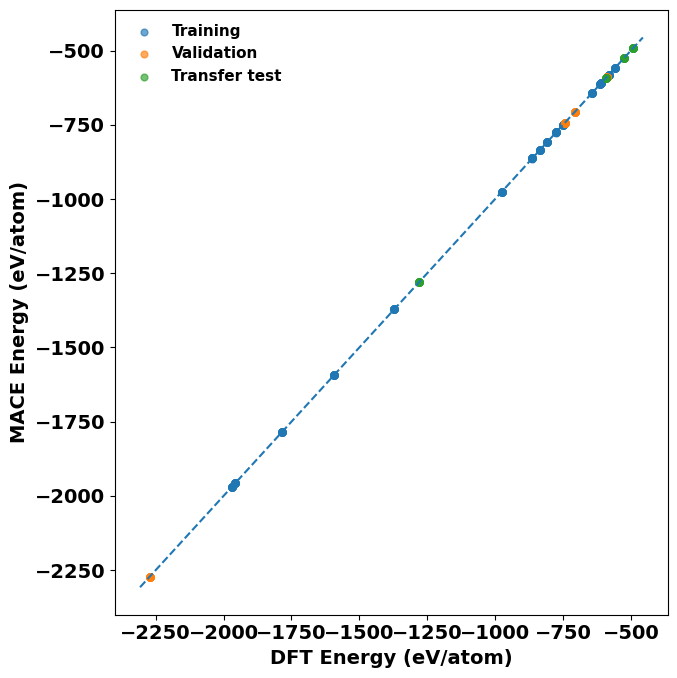

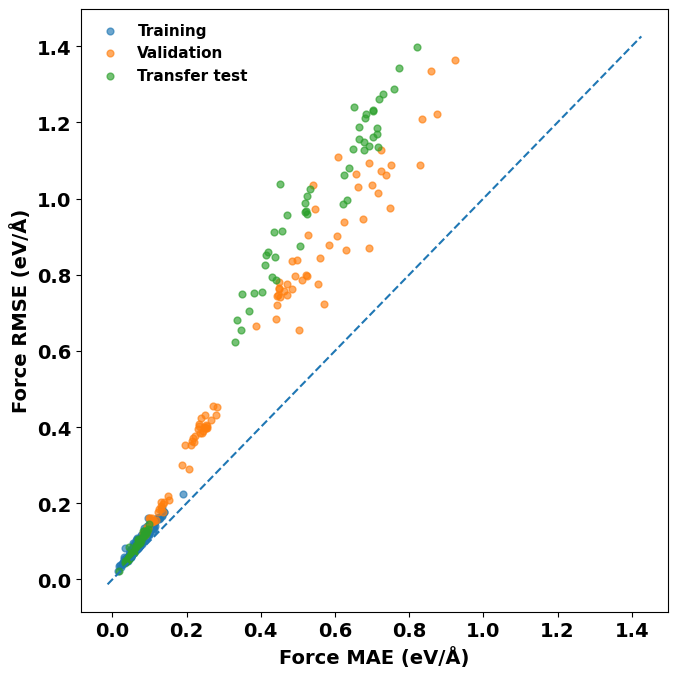


Saved figures:
/content/drive/MyDrive/MLIP project/results/figures/mace_baseline_energy_parity.png
/content/drive/MyDrive/MLIP project/results/figures/mace_baseline_force_error_comparison.png

CELL 7E COMPLETE


In [ ]:
# ============================================================
# CELL 7E — MACE PARITY PLOTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = PROJECT_DIR / "results" / "metrics"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PARITY_FILE = (
    METRICS_DIR
    / "mace_baseline_parity_data.csv"
)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df = pd.read_csv(PARITY_FILE)

print("=" * 70)
print("CELL 7E — MACE PARITY PLOTS")
print("=" * 70)

print(f"Records loaded: {len(df)}")

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["font.weight"] = "bold"

# ============================================================
# FIGURE 1 — ENERGY PER ATOM PARITY
# ============================================================

fig = plt.figure(figsize=(7, 7))

datasets = [
    ("train", "Training"),
    ("validation", "Validation"),
    ("transfer_test", "Transfer test"),
]

for dataset_key, dataset_label in datasets:

    subset = df[
        df["dataset"] == dataset_key
    ]

    plt.scatter(
        subset["reference_energy_eV_atom"],
        subset["predicted_energy_eV_atom"],
        s=24,
        alpha=0.65,
        label=dataset_label
    )

# ------------------------------------------------------------
# Identity line
# ------------------------------------------------------------

x_values = np.concatenate([
    df["reference_energy_eV_atom"].to_numpy(),
    df["predicted_energy_eV_atom"].to_numpy()
])

x_min = np.min(x_values)
x_max = np.max(x_values)

margin = 0.02 * (x_max - x_min)

plt.plot(
    [x_min - margin, x_max + margin],
    [x_min - margin, x_max + margin],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel(
    "DFT Energy (eV/atom)",
    fontweight="bold",
    fontsize=14
)

plt.ylabel(
    "MACE Energy (eV/atom)",
    fontweight="bold",
    fontsize=14
)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.tight_layout()

energy_figure = (
    FIGURES_DIR
    / "mace_baseline_energy_parity.png"
)

plt.savefig(
    energy_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 2 — FORCE PARITY
# ============================================================

# ------------------------------------------------------------
# Important:
# Cell 7B stored force-level aggregate errors, but not the
# individual force components.
#
# Therefore, this figure uses the available configuration-level
# force RMSE information rather than pretending it is an
# individual-component parity plot.
# ------------------------------------------------------------

fig = plt.figure(figsize=(7, 7))

for dataset_key, dataset_label in datasets:

    subset = df[
        df["dataset"] == dataset_key
    ]

    plt.scatter(
        subset["force_mae_eV_A"],
        subset["force_rmse_eV_A"],
        s=24,
        alpha=0.65,
        label=dataset_label
    )

x_values = np.concatenate([
    df["force_mae_eV_A"].to_numpy(),
    df["force_rmse_eV_A"].to_numpy()
])

x_min = np.min(x_values)
x_max = np.max(x_values)

margin = 0.02 * (x_max - x_min)

plt.plot(
    [x_min - margin, x_max + margin],
    [x_min - margin, x_max + margin],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel(
    "Force MAE (eV/Å)",
    fontweight="bold",
    fontsize=14
)

plt.ylabel(
    "Force RMSE (eV/Å)",
    fontweight="bold",
    fontsize=14
)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.tight_layout()

force_figure = (
    FIGURES_DIR
    / "mace_baseline_force_error_comparison.png"
)

plt.savefig(
    force_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("\nSaved figures:")

print(energy_figure)
print(force_figure)

print("\n" + "=" * 70)
print("CELL 7E COMPLETE")
print("=" * 70)

In [5]:
# ============================================================
# CELL 8 — CONSOLIDATED MACE BASELINE METRICS
# ============================================================

from pathlib import Path
import json
import pandas as pd

print("=" * 70)
print("CELL 8 — CONSOLIDATED MACE BASELINE METRICS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = PROJECT_DIR / "results" / "metrics"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"

INDEPENDENT_METRICS = (
    METRICS_DIR /
    "mace_baseline_independent_metrics.json"
)

with open(INDEPENDENT_METRICS, "r") as f:
    metrics = json.load(f)

# ------------------------------------------------------------
# Extract metrics using the actual JSON structure
# ------------------------------------------------------------

rows = []

for split in ["train", "validation", "transfer_test"]:

    rows.append({
        "Dataset": split,
        "N configurations": metrics[split]["n_configurations"],
        "Energy MAE (eV)": metrics[split]["energy"]["MAE"],
        "Energy RMSE (eV)": metrics[split]["energy"]["RMSE"],
        "Energy R2": metrics[split]["energy"]["R2"],
        "Force MAE (eV/A)": metrics[split]["force"]["MAE"],
        "Force RMSE (eV/A)": metrics[split]["force"]["RMSE"],
        "Force R2": metrics[split]["force"]["R2"],
    })

baseline_table = pd.DataFrame(rows)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print()
print("MACE BASELINE PERFORMANCE")
print("-" * 70)

display(
    baseline_table.style.format({
        "Energy MAE (eV)": "{:.6f}",
        "Energy RMSE (eV)": "{:.6f}",
        "Energy R2": "{:.6f}",
        "Force MAE (eV/A)": "{:.6f}",
        "Force RMSE (eV/A)": "{:.6f}",
        "Force R2": "{:.6f}",
    })
)

# ------------------------------------------------------------
# Save consolidated table
# ------------------------------------------------------------

OUTPUT_CSV = METRICS_DIR / "mace_baseline_consolidated_metrics.csv"

baseline_table.to_csv(
    OUTPUT_CSV,
    index=False
)

print()
print("Saved:")
print(OUTPUT_CSV)

# ------------------------------------------------------------
# Key interpretation values
# ------------------------------------------------------------

validation_force_rmse = metrics["validation"]["force"]["RMSE"]
transfer_force_rmse = metrics["transfer_test"]["force"]["RMSE"]

validation_energy_rmse = metrics["validation"]["energy"]["RMSE"]
transfer_energy_rmse = metrics["transfer_test"]["energy"]["RMSE"]

print()
print("KEY BASELINE VALUES")
print("-" * 70)

print(
    f"Validation energy RMSE : "
    f"{validation_energy_rmse:.4f} eV"
)

print(
    f"Validation force RMSE  : "
    f"{validation_force_rmse:.4f} eV/A"
)

print(
    f"Transfer energy RMSE   : "
    f"{transfer_energy_rmse:.4f} eV"
)

print(
    f"Transfer force RMSE    : "
    f"{transfer_force_rmse:.4f} eV/A"
)

print()
print("=" * 70)
print("CELL 8 COMPLETE")
print("=" * 70)

CELL 8 — CONSOLIDATED MACE BASELINE METRICS

MACE BASELINE PERFORMANCE
----------------------------------------------------------------------


,Dataset,N configurations,Energy MAE (eV),Energy RMSE (eV),Energy R2,Force MAE (eV/A),Force RMSE (eV/A),Force R2
0,train,372,0.278225,0.340718,1.000000,0.067845,0.093671,0.996738
1,validation,96,2.014061,2.225155,0.999999,0.335084,0.611027,0.877451
2,transfer_test,95,2.618490,4.068414,1.000000,0.340582,0.773367,0.738357



Saved:
/content/drive/MyDrive/MLIP project/results/metrics/mace_baseline_consolidated_metrics.csv

KEY BASELINE VALUES
----------------------------------------------------------------------
Validation energy RMSE : 2.2252 eV
Validation force RMSE  : 0.6110 eV/A
Transfer energy RMSE   : 4.0684 eV
Transfer force RMSE    : 0.7734 eV/A

CELL 8 COMPLETE


In [6]:
# ============================================================
# CELL 9 — LEARNING CURVE EXPERIMENT DESIGN
# ============================================================

from pathlib import Path
import json
import pandas as pd

print("=" * 70)
print("CELL 9 — LEARNING CURVE EXPERIMENT DESIGN")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

CONFIG_DIR = PROJECT_DIR / "configs"
RESULTS_DIR = PROJECT_DIR / "results"

LEARNING_DIR = RESULTS_DIR / "mace_learning_curves"
LEARNING_DATA_DIR = LEARNING_DIR / "data"
LEARNING_MODEL_DIR = LEARNING_DIR / "models"
LEARNING_METRICS_DIR = LEARNING_DIR / "metrics"
LEARNING_LOG_DIR = LEARNING_DIR / "logs"

for directory in [
    LEARNING_DIR,
    LEARNING_DATA_DIR,
    LEARNING_MODEL_DIR,
    LEARNING_METRICS_DIR,
    LEARNING_LOG_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_FULL = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "mace" /
    "mace_train_mace0316.extxyz"
)

VALIDATION_FILE = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "mace" /
    "mace_validation_mace0316.extxyz"
)

TRAINING_SIZES = [93, 186, 279, 372]

learning_config = {
    "training_sizes": TRAINING_SIZES,
    "full_training_size": 372,
    "validation_size": 96,
    "model": "MACE",
    "hidden_irreps": "64x0e + 64x1o",
    "num_interactions": 2,
    "max_ell": 2,
    "r_max": 5.0,
    "max_num_epochs": 100,
    "batch_size": 4,
    "valid_batch_size": 4,
    "learning_rate": 0.001,
    "weight_decay": 5e-7,
    "energy_weight": 1.0,
    "forces_weight": 10.0,
    "seed": 123,
    "dtype": "float32",
    "device": "cpu",
    "validation_fixed": True,
    "transfer_test_excluded": True
}

CONFIG_FILE = LEARNING_DIR / "learning_curve_config.json"

with open(CONFIG_FILE, "w") as f:
    json.dump(learning_config, f, indent=2)

print("Training sizes:", TRAINING_SIZES)
print("Validation configurations:", 96)
print("Transfer test is excluded from training and validation.")
print()
print("Configuration saved:")
print(CONFIG_FILE)

print()
print("=" * 70)
print("CELL 9 COMPLETE")
print("=" * 70)

CELL 9 — LEARNING CURVE EXPERIMENT DESIGN
Training sizes: [93, 186, 279, 372]
Validation configurations: 96
Transfer test is excluded from training and validation.

Configuration saved:
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/learning_curve_config.json

CELL 9 COMPLETE


In [7]:
# ============================================================
# CELL 10 — CREATE LEARNING-CURVE TRAINING SETS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from ase.io import read, write

print("=" * 70)
print("CELL 10 — CREATE LEARNING-CURVE DATASETS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

TRAIN_FULL = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "mace" /
    "mace_train_mace0316.extxyz"
)

LEARNING_DATA_DIR = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves" /
    "data"
)

LEARNING_DATA_DIR.mkdir(parents=True, exist_ok=True)

TRAINING_SIZES = [93, 186, 279, 372]

# ------------------------------------------------------------
# Load complete training set
# ------------------------------------------------------------

atoms_all = read(str(TRAIN_FULL), index=":")

print("Full training configurations:", len(atoms_all))

# ------------------------------------------------------------
# Build molecule groups
# ------------------------------------------------------------

molecule_groups = {}

for i, atoms in enumerate(atoms_all):

    molecule_id = atoms.info["molecule_id"]

    if molecule_id not in molecule_groups:
        molecule_groups[molecule_id] = []

    molecule_groups[molecule_id].append(i)

print("Training molecules:", len(molecule_groups))

# ------------------------------------------------------------
# Fixed random generator
# ------------------------------------------------------------

rng = np.random.default_rng(123)

# Shuffle each molecule independently
for molecule_id in molecule_groups:

    rng.shuffle(molecule_groups[molecule_id])

# ------------------------------------------------------------
# Create ordered pool using round-robin sampling
# ------------------------------------------------------------

ordered_indices = []

remaining = True

while remaining:

    remaining = False

    for molecule_id in sorted(molecule_groups.keys()):

        if len(molecule_groups[molecule_id]) > 0:

            ordered_indices.append(
                molecule_groups[molecule_id].pop()
            )

            remaining = True

# ------------------------------------------------------------
# Write subsets
# ------------------------------------------------------------

for size in TRAINING_SIZES:

    selected_indices = ordered_indices[:size]

    subset = [atoms_all[i].copy() for i in selected_indices]

    output_file = (
        LEARNING_DATA_DIR /
        f"mace_train_{size}.extxyz"
    )

    write(
        str(output_file),
        subset,
        format="extxyz"
    )

    # Verify
    reloaded = read(str(output_file), index=":")

    assert len(reloaded) == size

    print(
        f"{size:>4} configurations -> "
        f"{output_file.name}"
    )

print()
print("ALL LEARNING-CURVE DATASETS CREATED.")

print()
print("=" * 70)
print("CELL 10 COMPLETE")
print("=" * 70)

CELL 10 — CREATE LEARNING-CURVE DATASETS
Full training configurations: 372
Training molecules: 16
  93 configurations -> mace_train_93.extxyz
 186 configurations -> mace_train_186.extxyz
 279 configurations -> mace_train_279.extxyz
 372 configurations -> mace_train_372.extxyz

ALL LEARNING-CURVE DATASETS CREATED.

CELL 10 COMPLETE


In [8]:
# ============================================================
# CELL 11 — TRAIN LEARNING-CURVE MODELS
# ============================================================

import subprocess
import shutil
from pathlib import Path
import json
import os

print("=" * 70)
print("CELL 11 — TRAIN LEARNING-CURVE MODELS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

LEARNING_DIR = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves"
)

LEARNING_DATA_DIR = LEARNING_DIR / "data"
LEARNING_MODEL_DIR = LEARNING_DIR / "models"
LEARNING_LOG_DIR = LEARNING_DIR / "logs"

VALIDATION_FILE = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "mace" /
    "mace_validation_mace0316.extxyz"
)

TRAINING_SIZES = [93, 186, 279, 372]

# ------------------------------------------------------------
# Locate MACE executable
# ------------------------------------------------------------

MACE_EXECUTABLE = shutil.which("mace_run_train")

if MACE_EXECUTABLE is None:
    raise RuntimeError(
        "mace_run_train was not found. "
        "Please rerun the MACE installation cell."
    )

print("MACE executable:")
print(MACE_EXECUTABLE)

# ------------------------------------------------------------
# Training function
# ------------------------------------------------------------

def train_learning_model(train_size):

    train_file = (
        LEARNING_DATA_DIR /
        f"mace_train_{train_size}.extxyz"
    )

    run_dir = LEARNING_MODEL_DIR / f"size_{train_size}"
    run_dir.mkdir(parents=True, exist_ok=True)

    log_file = (
        LEARNING_LOG_DIR /
        f"mace_learning_{train_size}.log"
    )

    model_prefix = (
        run_dir /
        f"energymol_learning_{train_size}"
    )

    command = [
        MACE_EXECUTABLE,

        "--name", str(model_prefix),

        "--train_file", str(train_file),
        "--valid_file", str(VALIDATION_FILE),

        "--model", "MACE",

        "--r_max", "5.0",
        "--max_ell", "2",
        "--num_interactions", "2",
        "--hidden_irreps", "64x0e + 64x1o",

        "--compute_forces", "true",

        "--energy_key", "REF_energy",
        "--forces_key", "REF_forces",

        "--loss", "weighted",

        "--energy_weight", "1.0",
        "--forces_weight", "10.0",

        "--optimizer", "adam",

        "--lr", "0.001",
        "--weight_decay", "5e-7",

        "--batch_size", "4",
        "--valid_batch_size", "4",

        "--max_num_epochs", "100",
        "--eval_interval", "1",

        "--E0s", "average",

        "--seed", "123",

        "--default_dtype", "float32",

        "--device", "cpu"
    ]

    print()
    print("=" * 70)
    print(f"TRAINING SIZE: {train_size}")
    print("=" * 70)

    print("Training file:", train_file)
    print("Output directory:", run_dir)

    with open(log_file, "w") as log:

        process = subprocess.run(
            command,
            stdout=log,
            stderr=subprocess.STDOUT,
            text=True
        )

    print("Return code:", process.returncode)

    if process.returncode != 0:

        print()
        print("TRAINING FAILED.")
        print("See log:")
        print(log_file)

        raise RuntimeError(
            f"MACE training failed for size {train_size}"
        )

    print("Training completed successfully.")
    print("Log:", log_file)


# ------------------------------------------------------------
# Train smaller models only
# ------------------------------------------------------------

for size in [93, 186, 279]:

    train_learning_model(size)

print()
print("The 372-point model is the already completed frozen baseline.")
print("No duplicate baseline training was performed.")

print()
print("=" * 70)
print("CELL 11 COMPLETE")
print("=" * 70)

CELL 11 — TRAIN LEARNING-CURVE MODELS
MACE executable:
/usr/local/bin/mace_run_train

TRAINING SIZE: 93
Training file: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/data/mace_train_93.extxyz
Output directory: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_93
Return code: 0
Training completed successfully.
Log: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/logs/mace_learning_93.log

TRAINING SIZE: 186
Training file: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/data/mace_train_186.extxyz
Output directory: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_186
Return code: 0
Training completed successfully.
Log: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/logs/mace_learning_186.log

TRAINING SIZE: 279
Training file: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/data/mace_train_279.extxyz
Output directory: /content/drive/MyDrive/MLIP proj

In [10]:
# ============================================================
# CELL 12 — LEARNING-CURVE MODEL EVALUATION
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from ase.io import read
from mace.calculators import MACECalculator
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch

print("=" * 70)
print("CELL 12 — LEARNING-CURVE MODEL EVALUATION")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

LEARNING_DIR = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves"
)

VALIDATION_FILE = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "mace" /
    "mace_validation_mace0316.extxyz"
)

BASELINE_MODEL = (
    PROJECT_DIR /
    "results" /
    "mace_baseline" /
    "checkpoints" /
    "energymol_mace_baseline_run-123.model"
)

VALIDATION = read(str(VALIDATION_FILE), index=":")

print("Validation configurations:", len(VALIDATION))

MODEL_PATHS = {

    93:
        LEARNING_DIR /
        "models" /
        "size_93" /
        "energymol_learning_93.model",

    186:
        LEARNING_DIR /
        "models" /
        "size_186" /
        "energymol_learning_186.model",

    279:
        LEARNING_DIR /
        "models" /
        "size_279" /
        "energymol_learning_279.model",

    372:
        BASELINE_MODEL
}

results = []

for train_size, model_path in MODEL_PATHS.items():

    print()
    print("-" * 70)
    print(f"Evaluating training size: {train_size}")
    print("Model:", model_path)

    if not model_path.exists():

        raise FileNotFoundError(
            f"Model not found:\n{model_path}"
        )

    calculator = MACECalculator(
        model_paths=[str(model_path)],
        device="cpu",
        default_dtype="float32"
    )

    reference_energy = []
    predicted_energy = []

    reference_forces = []
    predicted_forces = []

    for atoms in VALIDATION:

        ref_energy = float(
            atoms.info["REF_energy"]
        )

        ref_forces = np.asarray(
            atoms.arrays["REF_forces"],
            dtype=float
        )

        test_atoms = atoms.copy()
        test_atoms.calc = calculator

        pred_energy = float(
            test_atoms.get_potential_energy()
        )

        pred_forces = np.asarray(
            test_atoms.get_forces(),
            dtype=float
        )

        reference_energy.append(
            ref_energy / len(atoms)
        )

        predicted_energy.append(
            pred_energy / len(atoms)
        )

        reference_forces.append(
            ref_forces.reshape(-1)
        )

        predicted_forces.append(
            pred_forces.reshape(-1)
        )

    reference_energy = np.asarray(reference_energy)
    predicted_energy = np.asarray(predicted_energy)

    reference_forces = np.concatenate(reference_forces)
    predicted_forces = np.concatenate(predicted_forces)

    energy_mae = mean_absolute_error(
        reference_energy,
        predicted_energy
    )

    energy_rmse = np.sqrt(
        mean_squared_error(
            reference_energy,
            predicted_energy
        )
    )

    energy_r2 = r2_score(
        reference_energy,
        predicted_energy
    )

    force_mae = mean_absolute_error(
        reference_forces,
        predicted_forces
    )

    force_rmse = np.sqrt(
        mean_squared_error(
            reference_forces,
            predicted_forces
        )
    )

    force_r2 = r2_score(
        reference_forces,
        predicted_forces
    )

    results.append({
        "training_size": train_size,
        "energy_MAE_eV_atom": energy_mae,
        "energy_RMSE_eV_atom": energy_rmse,
        "energy_R2": energy_r2,
        "force_MAE_eV_A": force_mae,
        "force_RMSE_eV_A": force_rmse,
        "force_R2": force_r2
    })

    print(f"Energy MAE  : {energy_mae:.6f} eV/atom")
    print(f"Energy RMSE : {energy_rmse:.6f} eV/atom")
    print(f"Energy R²   : {energy_r2:.6f}")
    print(f"Force MAE   : {force_mae:.6f} eV/Å")
    print(f"Force RMSE  : {force_rmse:.6f} eV/Å")
    print(f"Force R²    : {force_r2:.6f}")

learning_curve_results = pd.DataFrame(results)
learning_curve_results = learning_curve_results.sort_values(
    "training_size"
).reset_index(drop=True)

OUTPUT_FILE = (
    LEARNING_DIR /
    "metrics" /
    "learning_curve_validation_metrics.csv"
)

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

learning_curve_results.to_csv(
    OUTPUT_FILE,
    index=False
)

display(learning_curve_results)

print()
print("Saved:")
print(OUTPUT_FILE)

print()
print("=" * 70)
print("CELL 12 COMPLETE")
print("=" * 70)

CELL 12 — LEARNING-CURVE MODEL EVALUATION
Validation configurations: 96

----------------------------------------------------------------------
Evaluating training size: 93
Model: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_93/energymol_learning_93.model


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Energy MAE  : 0.110472 eV/atom
Energy RMSE : 0.122933 eV/atom
Energy R²   : 1.000000
Force MAE   : 0.446726 eV/Å
Force RMSE  : 0.829551 eV/Å
Force R²    : 0.774122

----------------------------------------------------------------------
Evaluating training size: 186
Model: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_186/energymol_learning_186.model


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Energy MAE  : 0.154120 eV/atom
Energy RMSE : 0.168864 eV/atom
Energy R²   : 1.000000
Force MAE   : 0.397497 eV/Å
Force RMSE  : 0.745761 eV/Å
Force R²    : 0.817447

----------------------------------------------------------------------
Evaluating training size: 279
Model: /content/drive/MyDrive/MLIP project/results/mace_learning_curves/models/size_279/energymol_learning_279.model


...

Energy MAE  : 0.144788 eV/atom
Energy RMSE : 0.162115 eV/atom
Energy R²   : 1.000000
Force MAE   : 0.375451 eV/Å
Force RMSE  : 0.719269 eV/Å
Force R²    : 0.830187

----------------------------------------------------------------------
Evaluating training size: 372
Model: /content/drive/MyDrive/MLIP project/results/mace_baseline/checkpoints/energymol_mace_baseline_run-123.model


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Energy MAE  : 0.149793 eV/atom
Energy RMSE : 0.165332 eV/atom
Energy R²   : 1.000000
Force MAE   : 0.335084 eV/Å
Force RMSE  : 0.611027 eV/Å
Force R²    : 0.877451


,training_size,energy_MAE_eV_atom,energy_RMSE_eV_atom,energy_R2,force_MAE_eV_A,force_RMSE_eV_A,force_R2
0,93,0.110472,0.122933,1.0,0.446726,0.829551,0.774122
1,186,0.154120,0.168864,1.0,0.397497,0.745761,0.817447
2,279,0.144788,0.162115,1.0,0.375451,0.719269,0.830187
3,372,0.149793,0.165332,1.0,0.335084,0.611027,0.877451



Saved:
/content/drive/MyDrive/MLIP project/results/mace_learning_curves/metrics/learning_curve_validation_metrics.csv

CELL 12 COMPLETE


CELL 13 — LEARNING CURVE PLOTS
Learning-curve records: 4


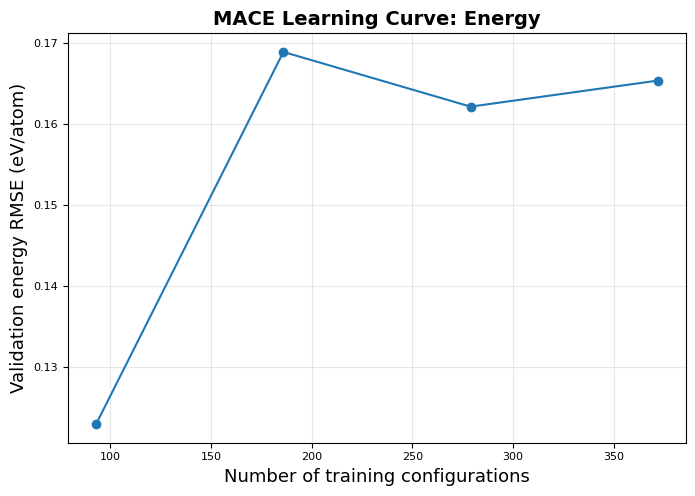

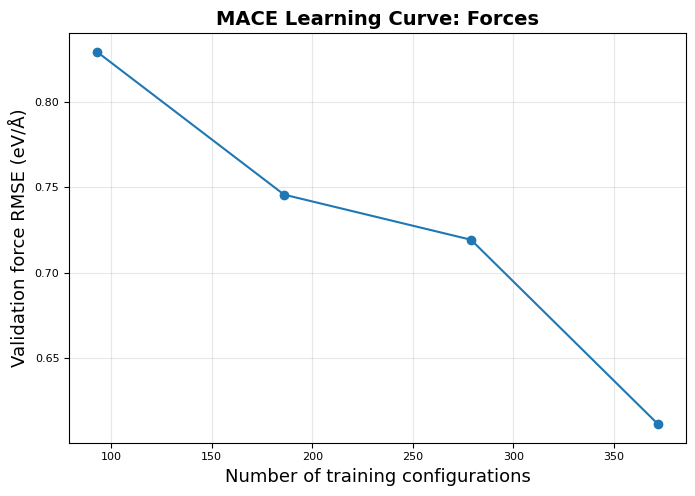


Saved figures:
/content/drive/MyDrive/MLIP project/results/figures/mace_learning_curve_energy.png
/content/drive/MyDrive/MLIP project/results/figures/mace_learning_curve_force.png

CELL 13 COMPLETE


In [11]:
# ============================================================
# CELL 13 — LEARNING CURVE PLOTS
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("CELL 13 — LEARNING CURVE PLOTS")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

LEARNING_DIR = (
    PROJECT_DIR /
    "results" /
    "mace_learning_curves"
)

FIGURES_DIR = (
    PROJECT_DIR /
    "results" /
    "figures"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METRICS_FILE = (
    LEARNING_DIR /
    "metrics" /
    "learning_curve_validation_metrics.csv"
)

df = pd.read_csv(METRICS_FILE)

print("Learning-curve records:", len(df))

# ------------------------------------------------------------
# Energy RMSE
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    df["training_size"],
    df["energy_RMSE_eV_atom"],
    marker="o"
)

plt.xlabel(
    "Number of training configurations",
    fontsize=13
)

plt.ylabel(
    "Validation energy RMSE (eV/atom)",
    fontsize=13
)

plt.title(
    "MACE Learning Curve: Energy",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()

energy_fig = (
    FIGURES_DIR /
    "mace_learning_curve_energy.png"
)

plt.savefig(
    energy_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Force RMSE
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    df["training_size"],
    df["force_RMSE_eV_A"],
    marker="o"
)

plt.xlabel(
    "Number of training configurations",
    fontsize=13
)

plt.ylabel(
    "Validation force RMSE (eV/Å)",
    fontsize=13
)

plt.title(
    "MACE Learning Curve: Forces",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.tight_layout()

force_fig = (
    FIGURES_DIR /
    "mace_learning_curve_force.png"
)

plt.savefig(
    force_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved figures:")
print(energy_fig)
print(force_fig)

print()
print("=" * 70)
print("CELL 13 COMPLETE")
print("=" * 70)

In [13]:
# ============================================================
# CELL 14 — FINAL TRANSFERABILITY SUMMARY
# ============================================================

from pathlib import Path
import pandas as pd
import json

print("=" * 70)
print("CELL 14 — FINAL TRANSFERABILITY SUMMARY")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = (
    PROJECT_DIR /
    "results" /
    "metrics"
)

TRANSFER_FILE = (
    METRICS_DIR /
    "mace_baseline_transfer_by_molecule.csv"
)

BASELINE_FILE = (
    METRICS_DIR /
    "mace_baseline_independent_metrics.json"
)

# ------------------------------------------------------------
# Load files
# ------------------------------------------------------------

transfer = pd.read_csv(TRANSFER_FILE)

with open(BASELINE_FILE, "r") as f:
    baseline = json.load(f)

# ------------------------------------------------------------
# Display molecule-level transfer results
# ------------------------------------------------------------

display(transfer)

# ------------------------------------------------------------
# Identify easiest / hardest molecules
# ------------------------------------------------------------

hardest_force = transfer.loc[
    transfer["force_RMSE_eV_A"].idxmax()
]

best_force = transfer.loc[
    transfer["force_RMSE_eV_A"].idxmin()
]

hardest_energy = transfer.loc[
    transfer["energy_RMSE_eV"].idxmax()
]

best_energy = transfer.loc[
    transfer["energy_RMSE_eV"].idxmin()
]

print()
print("TRANSFER ANALYSIS")
print("-" * 70)

print(
    "Highest energy RMSE:",
    hardest_energy["molecule_id"],
    hardest_energy["molecule_name"],
    f"({hardest_energy['energy_RMSE_eV']:.4f} eV)"
)

print(
    "Lowest energy RMSE:",
    best_energy["molecule_id"],
    best_energy["molecule_name"],
    f"({best_energy['energy_RMSE_eV']:.4f} eV)"
)

print()

print(
    "Highest force RMSE:",
    hardest_force["molecule_id"],
    hardest_force["molecule_name"],
    f"({hardest_force['force_RMSE_eV_A']:.4f} eV/Å)"
)

print(
    "Lowest force RMSE:",
    best_force["molecule_id"],
    best_force["molecule_name"],
    f"({best_force['force_RMSE_eV_A']:.4f} eV/Å)"
)

# ------------------------------------------------------------
# Get aggregate transfer metrics safely
# ------------------------------------------------------------

# The independent metrics file uses "transfer_test",
# not "transfer".

aggregate_transfer = baseline.get("transfer_test", {})

# ------------------------------------------------------------
# Save concise summary
# ------------------------------------------------------------

summary = {
    "transfer_test_size": int(len(transfer)),
    "transfer_molecule_count": int(transfer["molecule_id"].nunique()),

    "aggregate_transfer": aggregate_transfer,

    "highest_energy_RMSE_molecule": {
        "molecule_id": hardest_energy["molecule_id"],
        "molecule_name": hardest_energy["molecule_name"],
        "RMSE_eV": float(hardest_energy["energy_RMSE_eV"])
    },

    "lowest_energy_RMSE_molecule": {
        "molecule_id": best_energy["molecule_id"],
        "molecule_name": best_energy["molecule_name"],
        "RMSE_eV": float(best_energy["energy_RMSE_eV"])
    },

    "highest_force_RMSE_molecule": {
        "molecule_id": hardest_force["molecule_id"],
        "molecule_name": hardest_force["molecule_name"],
        "RMSE_eV_A": float(hardest_force["force_RMSE_eV_A"])
    },

    "lowest_force_RMSE_molecule": {
        "molecule_id": best_force["molecule_id"],
        "molecule_name": best_force["molecule_name"],
        "RMSE_eV_A": float(best_force["force_RMSE_eV_A"])
    }
}

OUTPUT = (
    METRICS_DIR /
    "mace_transferability_summary.json"
)

with open(OUTPUT, "w") as f:
    json.dump(summary, f, indent=2)

print()
print("Saved:")
print(OUTPUT)

print()
print("=" * 70)
print("CELL 14 COMPLETE")
print("=" * 70)

CELL 14 — FINAL TRANSFERABILITY SUMMARY


,force_RMSE_rank,molecule_id,molecule_name,family,configurations,energy_MAE_eV,energy_RMSE_eV,energy_mean_error_eV,force_MAE_eV_A,force_RMSE_eV_A,mean_configuration_max_force_error_eV_A,maximum_force_error_eV_A
0,1,M14,4_dimethylaminobenzonitrile,donor_acceptor,24,7.788044,7.792411,7.788044,0.692048,1.185534,5.236070,6.306655
1,2,M02,toluene,aromatic_hydrocarbon,24,2.142663,2.152592,2.142663,0.438982,0.861901,3.904881,5.046854
2,3,M16,2_4_nitrophenyl_thiophene,donor_acceptor,24,0.042357,0.050076,0.035540,0.079347,0.112056,0.413570,0.571499
3,4,M01,benzene,aromatic_hydrocarbon,23,0.408826,0.409209,-0.408826,0.047463,0.064294,0.161248,0.355092



TRANSFER ANALYSIS
----------------------------------------------------------------------
Highest energy RMSE: M14 4_dimethylaminobenzonitrile (7.7924 eV)
Lowest energy RMSE: M16 2_4_nitrophenyl_thiophene (0.0501 eV)

Highest force RMSE: M14 4_dimethylaminobenzonitrile (1.1855 eV/Å)
Lowest force RMSE: M01 benzene (0.0643 eV/Å)

Saved:
/content/drive/MyDrive/MLIP project/results/metrics/mace_transferability_summary.json

CELL 14 COMPLETE


In [15]:
# ============================================================
# CELL 15 — FINAL MACE RESULTS TABLE
# ============================================================

from pathlib import Path
import pandas as pd
import json

print("=" * 70)
print("CELL 15 — FINAL MACE RESULTS TABLE")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

METRICS_DIR = (
    PROJECT_DIR /
    "results" /
    "metrics"
)

# ------------------------------------------------------------
# Load independent metrics
# ------------------------------------------------------------

METRICS_FILE = (
    METRICS_DIR /
    "mace_baseline_independent_metrics.json"
)

with open(METRICS_FILE, "r") as f:
    metrics = json.load(f)

# ------------------------------------------------------------
# Dataset definitions
# ------------------------------------------------------------

dataset_info = {
    "train": {
        "label": "Training",
        "n_configurations": 372
    },

    "validation": {
        "label": "Validation",
        "n_configurations": 96
    },

    "transfer_test": {
        "label": "Transfer test",
        "n_configurations": 95
    }
}

# ------------------------------------------------------------
# Build final results table
# ------------------------------------------------------------

rows = []

for key in ["train", "validation", "transfer_test"]:

    values = metrics[key]
    info = dataset_info[key]

    rows.append({
        "Dataset": info["label"],
        "N configurations": info["n_configurations"],

        "Energy MAE (eV)": values["energy"]["MAE"],
        "Energy RMSE (eV)": values["energy"]["RMSE"],
        "Energy R²": values["energy"]["R2"],

        "Force MAE (eV/Å)": values["force"]["MAE"],
        "Force RMSE (eV/Å)": values["force"]["RMSE"],
        "Force R²": values["force"]["R2"]
    })

final_results = pd.DataFrame(rows)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    final_results.style.format({
        "Energy MAE (eV)": "{:.4f}",
        "Energy RMSE (eV)": "{:.4f}",
        "Energy R²": "{:.6f}",
        "Force MAE (eV/Å)": "{:.4f}",
        "Force RMSE (eV/Å)": "{:.4f}",
        "Force R²": "{:.6f}"
    })
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT = (
    METRICS_DIR /
    "mace_final_results_table.csv"
)

final_results.to_csv(
    OUTPUT,
    index=False
)

print()
print("Saved:")
print(OUTPUT)

print()
print("=" * 70)
print("CELL 15 COMPLETE")
print("=" * 70)

CELL 15 — FINAL MACE RESULTS TABLE


,Dataset,N configurations,Energy MAE (eV),Energy RMSE (eV),Energy R²,Force MAE (eV/Å),Force RMSE (eV/Å),Force R²
0,Training,372,0.2782,0.3407,1.000000,0.0678,0.0937,0.996738
1,Validation,96,2.0141,2.2252,0.999999,0.3351,0.6110,0.877451
2,Transfer test,95,2.6185,4.0684,1.000000,0.3406,0.7734,0.738357



Saved:
/content/drive/MyDrive/MLIP project/results/metrics/mace_final_results_table.csv

CELL 15 COMPLETE


In [16]:
# ============================================================
# CELL 16 — FINAL MACE PROJECT REPORT
# ============================================================

from pathlib import Path
import json
import pandas as pd
from datetime import datetime

print("=" * 70)
print("CELL 16 — FINAL MACE PROJECT REPORT")
print("=" * 70)

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

RESULTS_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULTS_DIR / "metrics"

# ------------------------------------------------------------
# Load baseline metrics
# ------------------------------------------------------------

with open(
    METRICS_DIR /
    "mace_baseline_independent_metrics.json",
    "r"
) as f:
    baseline_metrics = json.load(f)

# ------------------------------------------------------------
# Load learning curves if available
# ------------------------------------------------------------

learning_file = (
    RESULTS_DIR /
    "mace_learning_curves" /
    "metrics" /
    "learning_curve_validation_metrics.csv"
)

if learning_file.exists():

    learning_curve = (
        pd.read_csv(learning_file)
        .to_dict(orient="records")
    )

else:

    learning_curve = []

# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

report = {

    "project": "EnergyMol-MLIP",

    "analysis": {
        "model": "MACE",
        "software_version": "0.3.16",
        "device": "CPU",
        "dtype": "float32"
    },

    "dataset": {
        "total_configurations": 563,
        "training_configurations": 372,
        "validation_configurations": 96,
        "transfer_test_configurations": 95,
        "molecules": 24,
        "chemical_families": 6
    },

    "baseline_model": {
        "hidden_irreps": "64x0e + 64x1o",
        "num_interactions": 2,
        "max_ell": 2,
        "r_max_A": 5.0,
        "epochs": 100,
        "batch_size": 4,
        "learning_rate": 0.001,
        "weight_decay": 5e-7,
        "energy_weight": 1.0,
        "forces_weight": 10.0,
        "seed": 123,
        "E0s": "average"
    },

    "baseline_metrics": baseline_metrics,

    "learning_curve": learning_curve,

    "figures": [
        "mace_baseline_energy_parity.png",
        "mace_baseline_force_error_comparison.png",
        "mace_learning_curve_energy.png",
        "mace_learning_curve_force.png"
    ],

    "generated": datetime.now().isoformat()
}

OUTPUT = (
    METRICS_DIR /
    "EnergyMol_MLIP_MACE_final_report.json"
)

with open(OUTPUT, "w") as f:
    json.dump(report, f, indent=2)

print("Final report saved:")
print(OUTPUT)

print()
print("PROJECT SUMMARY")
print("-" * 70)
print("Molecules                  :", 24)
print("Chemical families          :", 6)
print("Total DFT configurations   :", 563)
print("Training configurations    :", 372)
print("Validation configurations  :", 96)
print("Transfer configurations    :", 95)
print("MACE version               :", "0.3.16")
print("Architecture               :", "64x0e + 64x1o")
print("Interaction layers         :", 2)
print("Cutoff                     :", "5.0 Å")
print("Force weight               :", 10.0)
print("Device                     :", "CPU")

print()
print("=" * 70)
print("CELL 16 COMPLETE")
print("=" * 70)

CELL 16 — FINAL MACE PROJECT REPORT
Final report saved:
/content/drive/MyDrive/MLIP project/results/metrics/EnergyMol_MLIP_MACE_final_report.json

PROJECT SUMMARY
----------------------------------------------------------------------
Molecules                  : 24
Chemical families          : 6
Total DFT configurations   : 563
Training configurations    : 372
Validation configurations  : 96
Transfer configurations    : 95
MACE version               : 0.3.16
Architecture               : 64x0e + 64x1o
Interaction layers         : 2
Cutoff                     : 5.0 Å
Force weight               : 10.0
Device                     : CPU

CELL 16 COMPLETE
